# 02_preprocessing.ipynb: Data Cleaning, Feature Engineering, and Transformation

## Objective

This notebook focuses on preparing the raw data for machine learning model training. Key objectives include:

1.  **Data Cleaning:** Handling missing values, addressing outliers, and correcting inconsistencies.
2.  **Feature Engineering:** Creating new features from existing ones (e.g., time-based features, interaction terms) to improve model performance.
3.  **Data Transformation:** Applying scaling (e.g., Min-Max scaling) and encoding (e.g., One-Hot Encoding) to ensure features are in a suitable format for the chosen machine learning algorithms.

The goal is to produce a clean, well-engineered, and transformed dataset ready for model development.

## Key Findings (To be filled by reviewer/user)

*   **Missing Values:** [Summarize how missing values were handled, e.g., 'Missing temperature data imputed using forward-fill.']
*   **New Features:** [List key engineered features, e.g., 'Created 'hour_of_day', 'day_of_week', and 'is_weekend' features.']
*   **Transformations:** [Describe scaling/encoding applied, e.g., 'Numerical features scaled using MinMaxScaler; 'route_id' one-hot encoded.']
*   **Data Readiness:** [Confirm data is prepared, e.g., 'The preprocessed data is now stored and ready for model training.']

In [3]:
import folium.plugins
import folium
import numpy as np  # Added for np.mean
from sklearn.preprocessing import MinMaxScaler
import joblib
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import holidays
from shapely.geometry import Point
import seaborn as sns
import matplotlib.pyplot as plt
import json  # Explicitly import json
from shapely.geometry import LineString
import geopandas
import os
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#02_preprocessing.ipynb: Data Preprocessing

This notebook focuses on preparing the data for model training. It includes loading the processed data from the previous phase, further feature engineering, and data transformations.

In [7]:
# Define the directory for processed data
processed_data_dir = '/content/drive/MyDrive/matatu_ml/data/processed/'

# Load the GTFS tables (from CSVs created in the previous notebook)
routes_df = pd.read_csv(os.path.join(processed_data_dir, 'routes.csv'))
stops_df = pd.read_csv(os.path.join(processed_data_dir, 'stops.csv'))
stop_times_df = pd.read_csv(os.path.join(processed_data_dir, 'stop_times.csv'))
shapes_df = pd.read_csv(os.path.join(
    processed_data_dir, 'shapes.csv'))  # Raw shapes data

print(f"Loaded routes_df. Shape: {routes_df.shape}")
print(f"Loaded stops_df. Shape: {stops_df.shape}")
print(f"Loaded stop_times_df. Shape: {stop_times_df.shape}")
print(f"Loaded shapes_df. Shape: {shapes_df.shape}")

# Recreate routes_gdf (GeoDataFrame of route geometries) from shapes_df


def create_linestring(group):
    return LineString(group[['shape_pt_lon', 'shape_pt_lat']].values)


# Sort by sequence to ensure correct line order
shapes_df_sorted = shapes_df.sort_values(by=['shape_id', 'shape_pt_sequence'])
geometries = shapes_df_sorted.groupby('shape_id').apply(
    create_linestring, include_groups=False)
routes_gdf = pd.DataFrame({'geometry': geometries}).reset_index()
routes_gdf = geopandas.GeoDataFrame(
    routes_gdf, geometry='geometry', crs="EPSG:4326")
print(f"Recreated routes_gdf. Shape: {routes_gdf.shape}")

# Load hourly weather data (from JSON)
json_file_path = '/content/nairobi_weather_2024.json'
with open(json_file_path, 'r') as f:
    weather_data = json.load(f)
hourly_df = pd.DataFrame(weather_data['hourly'])
hourly_df['time'] = pd.to_datetime(hourly_df['time'])
hourly_df.rename(columns={
    'rain': 'rainfall_mm',
    'temperature_2m': 'temperature_c',
    'wind_speed_10m': 'wind_speed'
}, inplace=True)
print(f"Loaded hourly_df. Shape: {hourly_df.shape}")

# Load EPRA fuel prices (from CSV)
epra_prices_path = '/content/Pump Prices  Energy and Petroleum Regulatory Authority.csv'
epra_df = pd.read_csv(epra_prices_path)
epra_df['From_Date'] = pd.to_datetime(epra_df['From'], format='%d-%m-%Y')
epra_df['To_Date'] = pd.to_datetime(epra_df['To'], format='%d-%m-%Y')
print(f"Loaded epra_df. Shape: {epra_df.shape}")

# Load POIs data (from CSV)
all_pois_output_path = os.path.join(processed_data_dir, 'routes_pois.csv')
# Use pandas to read the CSV, then convert to GeoDataFrame
pois_df_temp = pd.read_csv(all_pois_output_path)
# Re-assign geometry column and set CRS, as reading from CSV converts it to string/object
pois_df_temp['geometry'] = geopandas.GeoSeries.from_wkt(
    pois_df_temp['geometry'])
all_pois_gdf = geopandas.GeoDataFrame(
    pois_df_temp, geometry='geometry', crs='EPSG:4326')
print(f"Loaded all_pois_gdf. Shape: {all_pois_gdf.shape}")


print("\n--- DataFrames loaded successfully ---")
print("Head of routes_df:")
display(routes_df.head())
print("\nHead of stops_df:")
display(stops_df.head())
print("\nHead of stop_times_df:")
display(stop_times_df.head())
print("\nHead of shapes_df:")
display(shapes_df.head())
print("\nHead of routes_gdf:")
display(routes_gdf.head())
print("\nHead of hourly_df:")
display(hourly_df.head())
print("\nHead of epra_df:")
display(epra_df.head())
print("\nHead of all_pois_gdf:")
display(all_pois_gdf.head())

Loaded routes_df. Shape: (136, 5)
Loaded stops_df. Shape: (4273, 6)
Loaded stop_times_df. Shape: (7533, 5)
Loaded shapes_df. Shape: (36483, 4)
Recreated routes_gdf. Shape: (272, 2)
Loaded hourly_df. Shape: (18984, 4)
Loaded epra_df. Shape: (19, 7)
Loaded all_pois_gdf. Shape: (91758, 10)

--- DataFrames loaded successfully ---
Head of routes_df:


,route_id,agency_id,route_short_name,route_long_name,route_type
0,10000107D11,UON,107D,Ruaka-Ruiru,3
1,10000114011,UON,114R,Ngara-Rwaka-Ndenderu-Limuru,3
2,10000116011,UON,116,Koja-Ngara-Banana-Limuru,3
3,10100011A11,UON,11A,Odeon-Aga Khan-Highridge,3
4,10200010811,UON,108,UN-New Muthaiga-Gachie-Gichagi,3



Head of stops_df:


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station
0,0001RLW,Railways,-1.290884,36.828242,0.0,NaN
1,010044G,44 Githurai,-1.195514,36.902695,NaN,NaN
2,0100AAA,Sahala,-1.206232,36.790681,NaN,NaN
3,0100AAE,Aga Khan Hospital Entrance,-1.261770,36.822180,NaN,NaN
4,0100ACP,PCEA,-1.184213,36.907515,NaN,NaN



Head of stop_times_df:


...

,time,temperature_c,rainfall_mm,wind_speed
0,2024-01-01 00:00:00,15.4,0.0,4.6
1,2024-01-01 01:00:00,16.6,0.0,3.6
2,2024-01-01 02:00:00,15.8,0.0,6.2
3,2024-01-01 03:00:00,15.4,0.0,6.4
4,2024-01-01 04:00:00,16.4,0.0,4.4



Head of epra_df:


,From,To,Town,Super (PMS),Diesel (AGO),From_Date,To_Date
0,15-12-2025,14-01-2026,Nairobi,184.52,171.47,2025-12-15,2026-01-14
1,15-11-2025,14-12-2025,Nairobi,184.52,171.47,2025-11-15,2025-12-14
2,15-10-2025,14-11-2025,Nairobi,184.52,171.47,2025-10-15,2025-11-14
3,15-09-2025,14-10-2025,Nairobi,184.52,171.47,2025-09-15,2025-10-14
4,15-08-2025,14-09-2025,Nairobi,185.31,171.58,2025-08-15,2025-09-14



Head of all_pois_gdf:


,osm_id,geometry,element_type,name,amenity,shop,office,building,healthcare,shape_id
0,MISSING_OSMID_10106110_0_6e89b158,POINT (36.81492 -1.27217),NaN,Aga Khan Nursery,school,NaN,NaN,NaN,NaN,10106110
1,MISSING_OSMID_10106110_1_c3db3ca2,POINT (36.80451 -1.23001),NaN,City Walk - Village Market,NaN,shoes,NaN,NaN,NaN,10106110
2,MISSING_OSMID_10106110_2_721dabaf,POINT (36.80146 -1.22415),NaN,River Garden Centre,NaN,garden_centre,NaN,NaN,NaN,10106110
3,MISSING_OSMID_10106110_3_a5b4225b,POINT (36.82025 -1.24999),NaN,Onn The Way Supermarket Muthaiga,NaN,supermarket,NaN,NaN,NaN,10106110
4,MISSING_OSMID_10106110_4_71ec95ac,POINT (36.80496 -1.22869),NaN,Dorman,NaN,mall,NaN,NaN,NaN,10106110


#Temporal Alignment and Resampling

Now, I will align and resample the hourly_df (weather data) and epra_df (fuel prices) to a common hourly time index. This ensures that all temporal data points are synchronized, which is crucial for building accurate predictive models.

Since epra_df is monthly, I'll resample it to hourly using forward-fill (ffill) to propagate the last known price for the entire month until the next price update. Then, I'll create a unified hourly index that covers the entire span of both datasets and reindex both dataframes to this common index before merging them.


In [9]:
# 2. Temporal Alignment and Resampling

# Set 'time' as index for hourly_df
hourly_df = hourly_df.set_index('time').sort_index()
print(f"hourly_df after setting index: {hourly_df.shape}")

# Process EPRA fuel prices for hourly alignment
# First, ensure 'From_Date' and 'To_Date' are datetime objects
epra_df['From_Date'] = pd.to_datetime(epra_df['From_Date'])
epra_df['To_Date'] = pd.to_datetime(epra_df['To_Date'])

# Create a new DataFrame for hourly fuel prices
min_date = hourly_df.index.min()
max_date = hourly_df.index.max()

# Create a continuous hourly time range covering the span of the weather data
full_hourly_range = pd.date_range(
    start=min_date, end=max_date, freq='h')  # Changed 'H' to 'h'

# Initialize an empty DataFrame to store hourly EPRA prices
hourly_epra_data = []

# Iterate through each row of epra_df and expand to hourly entries
for idx, row in epra_df.iterrows():
    price_range_start = row['From_Date'].to_numpy()
    price_range_end = row['To_Date'].to_numpy(
        # Include the end day fully
    ) + pd.Timedelta(hours=23, minutes=59, seconds=59)

    # Filter the full_hourly_range to only include dates within the current EPRA price period
    valid_hours_in_range = full_hourly_range[(
        full_hourly_range >= price_range_start) & (full_hourly_range <= price_range_end)]

    for hour in valid_hours_in_range:
        hourly_epra_data.append({
            'time': hour,
            'Super (PMS)': row['Super (PMS)'],
            'Diesel (AGO)': row['Diesel (AGO)']
        })

hourly_epra_df = pd.DataFrame(hourly_epra_data).set_index('time').sort_index()

# Drop duplicate indices if any (e.g., if ranges overlap slightly, keep last)
hourly_epra_df = hourly_epra_df[~hourly_epra_df.index.duplicated(keep='last')]

# Reindex to the full hourly range to ensure all hours are present and forward fill missing values
hourly_epra_df = hourly_epra_df.reindex(full_hourly_range, method='ffill')

print(
    f"hourly_epra_df after resampling and forward-filling: {hourly_epra_df.shape}")
print("Head of hourly_epra_df:")
display(hourly_epra_df.head())

# Now, align hourly_df and hourly_epra_df on their common index
# We will use pandas.merge_asof for this as it handles 'nearest' or 'previous' matches, often useful for time series
# However, since both are already on a common hourly index, a simple join will suffice after ensuring common time range.

# First, ensure both dataframes cover the same time range
# Find the common start and end time
common_start = max(hourly_df.index.min(), hourly_epra_df.index.min())
common_end = min(hourly_df.index.max(), hourly_epra_df.index.max())

# Filter both dataframes to this common range
hourly_df_aligned = hourly_df.loc[common_start:common_end]
hourly_epra_df_aligned = hourly_epra_df.loc[common_start:common_end]

# Now, merge them. Since they have the same index, a simple concatenation or join works.
aligned_hourly_data_df = pd.concat(
    [hourly_df_aligned, hourly_epra_df_aligned], axis=1)

print(
    f"Aligned hourly data (weather + fuel). Shape: {aligned_hourly_data_df.shape}")
print("Head of aligned_hourly_data_df:")
display(aligned_hourly_data_df.head())

# For stop_times_df, we will extract date and hour components for merging later
# (This will be done in the feature engineering step)

hourly_df after setting index: (18984, 3)
hourly_epra_df after resampling and forward-filling: (18984, 2)
Head of hourly_epra_df:


,Super (PMS),Diesel (AGO)
2024-01-01 00:00:00,NaN,NaN
2024-01-01 01:00:00,NaN,NaN
2024-01-01 02:00:00,NaN,NaN
2024-01-01 03:00:00,NaN,NaN
2024-01-01 04:00:00,NaN,NaN


Aligned hourly data (weather + fuel). Shape: (18984, 5)
Head of aligned_hourly_data_df:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO)
2024-01-01 00:00:00,15.4,0.0,4.6,NaN,NaN
2024-01-01 01:00:00,16.6,0.0,3.6,NaN,NaN
2024-01-01 02:00:00,15.8,0.0,6.2,NaN,NaN
2024-01-01 03:00:00,15.4,0.0,6.4,NaN,NaN
2024-01-01 04:00:00,16.4,0.0,4.4,NaN,NaN


In [10]:
# 3. Impute missing values using forward-fill (ffill)
aligned_hourly_data_df_imputed = aligned_hourly_data_df.ffill()

print("Shape of aligned_hourly_data_df_imputed after ffill:",
      aligned_hourly_data_df_imputed.shape)
print("Missing values after ffill (should only be at the beginning if any):")
print(aligned_hourly_data_df_imputed.isnull().sum())

print("Head of aligned_hourly_data_df_imputed:")
display(aligned_hourly_data_df_imputed.head())

Shape of aligned_hourly_data_df_imputed after ffill: (18984, 5)
Missing values after ffill (should only be at the beginning if any):
temperature_c       0
rainfall_mm         0
wind_speed          0
Super (PMS)      7656
Diesel (AGO)     7656
dtype: int64
Head of aligned_hourly_data_df_imputed:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO)
2024-01-01 00:00:00,15.4,0.0,4.6,NaN,NaN
2024-01-01 01:00:00,16.6,0.0,3.6,NaN,NaN
2024-01-01 02:00:00,15.8,0.0,6.2,NaN,NaN
2024-01-01 03:00:00,15.4,0.0,6.4,NaN,NaN
2024-01-01 04:00:00,16.4,0.0,4.4,NaN,NaN


In [11]:
print('--- Applying Backward Fill (bfill) to remaining nulls ---')

# The DataFrame `aligned_hourly_data_df_imputed` from the previous cell
# already has forward-filled values. Now we apply backward fill to address NaNs at the beginning.
aligned_hourly_data_df_fully_imputed = aligned_hourly_data_df_imputed.bfill()

print("Remaining missing values imputed using backward fill.")

# Display the first few rows after bfill imputation
print("Head of aligned_hourly_data_df_fully_imputed after bfill imputation:")
display(aligned_hourly_data_df_fully_imputed.head())

# Display the null counts again to confirm full imputation
print('\nNull Counts after bfill imputation:')
print(aligned_hourly_data_df_fully_imputed.isnull().sum())

# Overwrite the aligned_hourly_data_df with the fully imputed version
aligned_hourly_data_df = aligned_hourly_data_df_fully_imputed

# Save the fully imputed DataFrame to CSV
aligned_hourly_fully_imputed_output_path = os.path.join(
    processed_data_dir, 'aligned_hourly_fully_imputed.csv')
aligned_hourly_data_df_fully_imputed.to_csv(
    aligned_hourly_fully_imputed_output_path, index=False)
print(
    f"Fully imputed aligned hourly data saved to {aligned_hourly_fully_imputed_output_path}")

--- Applying Backward Fill (bfill) to remaining nulls ---
Remaining missing values imputed using backward fill.
Head of aligned_hourly_data_df_fully_imputed after bfill imputation:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO)
2024-01-01 00:00:00,15.4,0.0,4.6,180.66,168.06
2024-01-01 01:00:00,16.6,0.0,3.6,180.66,168.06
2024-01-01 02:00:00,15.8,0.0,6.2,180.66,168.06
2024-01-01 03:00:00,15.4,0.0,6.4,180.66,168.06
2024-01-01 04:00:00,16.4,0.0,4.4,180.66,168.06



Null Counts after bfill imputation:
temperature_c    0
rainfall_mm      0
wind_speed       0
Super (PMS)      0
Diesel (AGO)     0
dtype: int64
Fully imputed aligned hourly data saved to /content/drive/MyDrive/matatu_ml/data/processed/aligned_hourly_fully_imputed.csv


## 4. Calculate Correlation between Weather Features and Fuel Prices

Now, we will examine the relationships between our weather features (temperature_c, rainfall_mm, wind_speed) and fuel prices (Super (PMS), Diesel (AGO)) by calculating their correlation matrix.

Correlation Matrix between Weather Features and Fuel Prices:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO)
temperature_c,1.000000,-0.033973,0.615486,-0.043264,0.008734
rainfall_mm,-0.033973,1.000000,-0.009872,-0.044410,-0.033395
wind_speed,0.615486,-0.009872,1.000000,0.040911,0.124248
Super (PMS),-0.043264,-0.044410,0.040911,1.000000,0.923405
Diesel (AGO),0.008734,-0.033395,0.124248,0.923405,1.000000


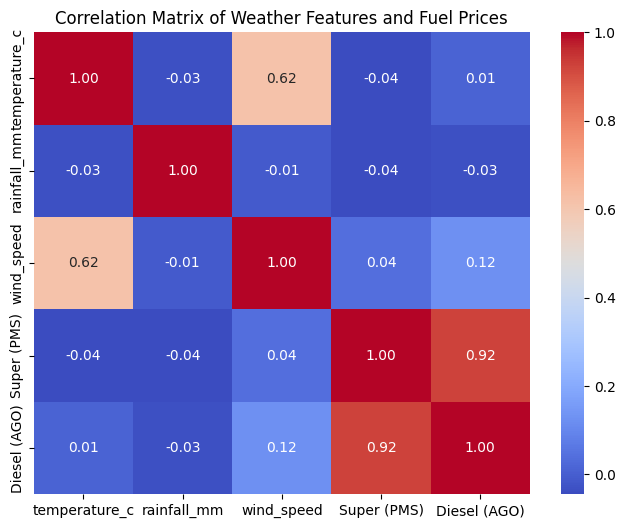

In [12]:
# Select relevant columns for correlation analysis
correlation_columns = [
    'temperature_c',
    'rainfall_mm',
    'wind_speed',
    'Super (PMS)',
    'Diesel (AGO)'
]

# Calculate the correlation matrix
correlation_matrix = aligned_hourly_data_df[correlation_columns].corr()

print("Correlation Matrix between Weather Features and Fuel Prices:")
display(correlation_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Weather Features and Fuel Prices')
plt.show()

## 5. Spatial Join: Attaching OSM POI Density to Route-Stops

This step is crucial for enriching our public transport stop data with contextual information about the surrounding environment. By spatially joining Points of Interest (POIs) with each stop, we can understand the commercial, residential, and activity density around each stop. This information can be vital for:

*   **Predicting Ridership:** Stops with higher POI density (e.g., shops, offices, schools) might experience higher passenger traffic.
*   **Route Optimization:** Understanding the services and amenities available near stops can help in planning more efficient and user-centric routes.
*   **Demand Modeling:** The type and density of POIs can serve as significant features in models predicting travel demand and service quality.
*   **Identifying Key Hubs:** Stops with a high concentration of diverse POIs could indicate important transit hubs or areas of high activity.

We will create a 500m buffer around each stop and count the number of unique POIs falling within that buffer. This will provide a numerical representation of the 'activity' or 'density' around each stop.

In [13]:
# Convert stops_df to a GeoDataFrame
# Ensure 'stop_lon' and 'stop_lat' are numeric
stops_df['stop_lon'] = pd.to_numeric(stops_df['stop_lon'], errors='coerce')
stops_df['stop_lat'] = pd.to_numeric(stops_df['stop_lat'], errors='coerce')

# Drop rows with NaN values in 'stop_lon' or 'stop_lat' after conversion
stops_gdf = stops_df.dropna(subset=['stop_lon', 'stop_lat']).copy()

stops_gdf['geometry'] = stops_gdf.apply(
    lambda row: Point(row['stop_lon'], row['stop_lat']), axis=1)
stops_gdf = geopandas.GeoDataFrame(
    stops_gdf, geometry='geometry', crs="EPSG:4326")

# Ensure all_pois_gdf also has a valid CRS, which it should from previous loading
if all_pois_gdf.crs is None:
    all_pois_gdf.set_crs("EPSG:4326", inplace=True)

print(f"stops_gdf shape: {stops_gdf.shape}")
print(f"all_pois_gdf shape: {all_pois_gdf.shape}")

# Reproject to a projected CRS for accurate buffering (e.g., UTM zone for Nairobi)
# Nairobi is in UTM Zone 37S, EPSG:32737
stops_gdf_proj = stops_gdf.to_crs(epsg=32737)
all_pois_gdf_proj = all_pois_gdf.to_crs(epsg=32737)

# Define buffer distance in meters
buffer_distance_meters = 500

# Create buffers around stops
stops_buffered = stops_gdf_proj.copy()
stops_buffered['geometry'] = stops_gdf_proj.geometry.buffer(
    buffer_distance_meters)

print(f"Stops buffered shape: {stops_buffered.shape}")

# Perform spatial join between buffered stops and POIs
# Use 'within' predicate to find POIs within each stop's buffer
stop_pois_sjoin = geopandas.sjoin(
    all_pois_gdf_proj, stops_buffered, how="inner", predicate="within")

print(f"Spatial join result shape: {stop_pois_sjoin.shape}")

# Calculate the number of unique POIs per stop
poi_counts_per_stop = stop_pois_sjoin.groupby(
    'stop_id').size().reset_index(name='poi_count_500m')

# Merge the POI counts back to the original stops_gdf
stops_gdf = stops_gdf.merge(poi_counts_per_stop, on='stop_id', how='left')

# Fill NaN values (stops with no POIs within buffer) with 0
stops_gdf['poi_count_500m'] = stops_gdf['poi_count_500m'].fillna(0).astype(int)

print("\nStops GeoDataFrame with POI counts:")
display(stops_gdf.head())
print(f"Final stops_gdf shape with POI counts: {stops_gdf.shape}")

stops_with_poi_output_path = os.path.join(
    processed_data_dir, 'stops_with_poi.geojson')
stops_gdf.to_file(stops_with_poi_output_path, driver='GeoJSON')

print(
    f"Stops GeoDataFrame with POI counts saved to: {stops_with_poi_output_path}")

stops_gdf shape: (4273, 7)
all_pois_gdf shape: (91758, 10)
Stops buffered shape: (4273, 7)
Spatial join result shape: (1335939, 17)

Stops GeoDataFrame with POI counts:


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,geometry,poi_count_500m
0,0001RLW,Railways,-1.290884,36.828242,0.0,NaN,POINT (36.82824 -1.29088),3200
1,010044G,44 Githurai,-1.195514,36.902695,NaN,NaN,POINT (36.9027 -1.19551),2
2,0100AAA,Sahala,-1.206232,36.790681,NaN,NaN,POINT (36.79068 -1.20623),6
3,0100AAE,Aga Khan Hospital Entrance,-1.261770,36.822180,NaN,NaN,POINT (36.82218 -1.26177),165
4,0100ACP,PCEA,-1.184213,36.907515,NaN,NaN,POINT (36.90752 -1.18421),4


Final stops_gdf shape with POI counts: (4273, 8)
Stops GeoDataFrame with POI counts saved to: /content/drive/MyDrive/matatu_ml/data/processed/stops_with_poi.geojson


### Distribution of POI Density

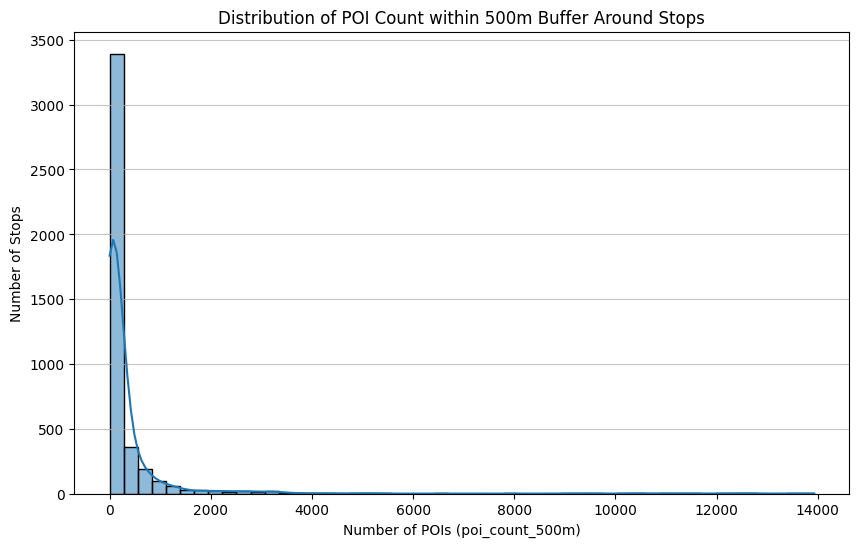

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(stops_gdf['poi_count_500m'], bins=50, kde=True)
plt.title('Distribution of POI Count within 500m Buffer Around Stops')
plt.xlabel('Number of POIs (poi_count_500m)')
plt.ylabel('Number of Stops')
plt.grid(axis='y', alpha=0.75)
plt.show()

## 6. Feature Engineering: Lag Features for Demand

To engineer lag features, we first need a 'demand' variable. Since we are working with GTFS schedule data, we'll create a synthetic 'scheduled demand' feature by counting the number of unique scheduled stop events (`trip_id` and `stop_id` combinations) per hour of the day. This provides a baseline hourly demand profile based on the public transport schedule. We'll then merge this with our `aligned_hourly_data_df` and compute the lag features.

In [15]:
# 6.1 Create a 'scheduled_demand_count' feature from stop_times_df

# Convert arrival_time to datetime objects (handling potential multiple days if times cross midnight, though GTFS usually resets daily)
# For simplicity here, we'll just extract the hour of the day from the time string.
stop_times_df['arrival_hour_of_day'] = pd.to_datetime(
    stop_times_df['arrival_time'], format='%H:%M:%S').dt.hour

# Count the number of unique trip-stop combinations per hour of the day as a proxy for 'scheduled demand'
# This represents how busy a given hour is across the entire system based on the schedule.
# We count the number of unique (trip_id, stop_id) pairs that occur at each hour of the day.
hourly_scheduled_demand = stop_times_df.groupby('arrival_hour_of_day').agg(
    # Count total scheduled events per hour
    scheduled_demand_count=('trip_id', 'size')
).reset_index()

print("Hourly Scheduled Demand Profile:")
display(hourly_scheduled_demand.head())

# Prepare aligned_hourly_data_df for merging
feature_df = aligned_hourly_data_df.copy()

# Preserve the DateTimeIndex by converting it to a column before merging
feature_df = feature_df.reset_index().rename(columns={'index': 'time'})

feature_df['hour_of_day'] = feature_df['time'].dt.hour

# Merge the scheduled demand count into the hourly feature_df
feature_df = feature_df.merge(
    hourly_scheduled_demand, left_on='hour_of_day', right_on='arrival_hour_of_day', how='left')

# Drop the temporary merging columns
feature_df.drop(columns=['hour_of_day', 'arrival_hour_of_day'], inplace=True)

# Set the 'time' column back as the index
feature_df = feature_df.set_index('time')

# Ensure the DataFrame is sorted by time after setting the index
feature_df.sort_index(inplace=True)

print(
    f"Feature DataFrame shape after adding scheduled demand: {feature_df.shape}")
print("Head of Feature DataFrame with scheduled_demand_count:")
display(feature_df.head())

Hourly Scheduled Demand Profile:


,arrival_hour_of_day,scheduled_demand_count
0,6,7119
1,7,414


Feature DataFrame shape after adding scheduled demand: (18984, 6)
Head of Feature DataFrame with scheduled_demand_count:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),scheduled_demand_count
time,,,,,,
2024-01-01 00:00:00,15.4,0.0,4.6,180.66,168.06,NaN
2024-01-01 01:00:00,16.6,0.0,3.6,180.66,168.06,NaN
2024-01-01 02:00:00,15.8,0.0,6.2,180.66,168.06,NaN
2024-01-01 03:00:00,15.4,0.0,6.4,180.66,168.06,NaN
2024-01-01 04:00:00,16.4,0.0,4.4,180.66,168.06,NaN


In [16]:
# 6.2 Engineer Lag Features for 'scheduled_demand_count'

# Ensure the DataFrame is sorted by time before creating lag features
feature_df.sort_index(inplace=True)

# Create 1-hour lag
feature_df['demand_lag_1h'] = feature_df['scheduled_demand_count'].shift(1)

# Create 24-hour lag
feature_df['demand_lag_24h'] = feature_df['scheduled_demand_count'].shift(24)

# Create 168-hour lag (same hour last week)
feature_df['demand_lag_168h'] = feature_df['scheduled_demand_count'].shift(168)

print("Head of Feature DataFrame with new lag features:")
display(feature_df.head(200))

print("Tail of Feature DataFrame to check for NaNs at the beginning due to shifting:")
display(feature_df.tail())

Head of Feature DataFrame with new lag features:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),scheduled_demand_count,demand_lag_1h,demand_lag_24h,demand_lag_168h
time,,,,,,,,,
2024-01-01 00:00:00,15.4,0.0,4.6,180.66,168.06,NaN,NaN,NaN,NaN
2024-01-01 01:00:00,16.6,0.0,3.6,180.66,168.06,NaN,NaN,NaN,NaN
2024-01-01 02:00:00,15.8,0.0,6.2,180.66,168.06,NaN,NaN,NaN,NaN
2024-01-01 03:00:00,15.4,0.0,6.4,180.66,168.06,NaN,NaN,NaN,NaN
2024-01-01 04:00:00,16.4,0.0,4.4,180.66,168.06,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2024-01-09 03:00:00,14.5,0.0,7.2,180.66,168.06,NaN,NaN,NaN,NaN
2024-01-09 04:00:00,14.9,0.0,8.8,180.66,168.06,NaN,NaN,NaN,NaN
2024-01-09 05:00:00,17.8,0.0,10.1,180.66,168.06,NaN,NaN,NaN,NaN


Tail of Feature DataFrame to check for NaNs at the beginning due to shifting:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),scheduled_demand_count,demand_lag_1h,demand_lag_24h,demand_lag_168h
time,,,,,,,,,
2026-03-01 19:00:00,16.9,0.1,1.5,178.28,166.54,NaN,NaN,NaN,NaN
2026-03-01 20:00:00,16.5,0.7,8.6,178.28,166.54,NaN,NaN,NaN,NaN
2026-03-01 21:00:00,16.1,0.4,6.0,178.28,166.54,NaN,NaN,NaN,NaN
2026-03-01 22:00:00,15.8,0.5,5.3,178.28,166.54,NaN,NaN,NaN,NaN
2026-03-01 23:00:00,15.6,0.1,6.2,178.28,166.54,NaN,NaN,NaN,NaN


## 7. Save the Enriched Feature DataFrame

Now that we have engineered the lag features, we will save the `feature_df` to a CSV file. This DataFrame contains all the aligned temporal data (weather, fuel prices) and the newly created scheduled demand with its lag features, ready for model training.

In [17]:
final_feature_df_path = os.path.join(
    processed_data_dir, 'time_series_features.csv')
# Save index as it contains the time information
feature_df.to_csv(final_feature_df_path, index=True)

print(f"Enriched feature DataFrame saved to: {final_feature_df_path}")

Enriched feature DataFrame saved to: /content/drive/MyDrive/matatu_ml/data/processed/time_series_features.csv


## 8. Handle Missing Values (NaNs) in Engineered Feature DataFrame

After creating lag features and merging scheduled demand, some `NaN` values are present, especially at the beginning of the time series for lag features and for hours without scheduled demand. We will inspect these and then impute them, typically with 0 for demand-related features, as a `NaN` implies no scheduled activity or a non-existent past value.

In [20]:
print("Missing values in feature_df before final imputation:")
display(feature_df.isnull().sum())

# With rows containing NaN lag features dropped, these fillna calls are now mostly for safety
# for any other potential NaNs that might arise, but not for initial lag NaNs.
feature_df['scheduled_demand_count'] = feature_df['scheduled_demand_count'].fillna(
    0)
feature_df['demand_lag_1h'] = feature_df['demand_lag_1h'].fillna(0)
feature_df['demand_lag_24h'] = feature_df['demand_lag_24h'].fillna(0)
feature_df['demand_lag_168h'] = feature_df['demand_lag_168h'].fillna(0)

print("\nMissing values in feature_df after final imputation:")
display(feature_df.isnull().sum())

print("\nHead of feature_df after final NaN imputation:")
# Display enough rows to see the imputed lag features
display(feature_df.head(200))
final_processed_feature_df_path = os.path.join(
    processed_data_dir, 'time_series_features_cleaned.csv')
# Save index as it contains the time information
feature_df.to_csv(final_processed_feature_df_path, index=True)

print(
    f"Fully processed feature DataFrame saved to: {final_processed_feature_df_path}")

Missing values in feature_df before final imputation:


,0
temperature_c,0
rainfall_mm,0
wind_speed,0
Super (PMS),0
Diesel (AGO),0
scheduled_demand_count,17402
demand_lag_1h,17402
demand_lag_24h,17404
demand_lag_168h,17416
hour_of_day,0



Missing values in feature_df after final imputation:


,0
temperature_c,0
rainfall_mm,0
wind_speed,0
Super (PMS),0
Diesel (AGO),0
scheduled_demand_count,0
demand_lag_1h,0
demand_lag_24h,0
demand_lag_168h,0
hour_of_day,0



Head of feature_df after final NaN imputation:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),scheduled_demand_count,demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter
time,,,,,,,,,,,,,,
2024-01-01 00:00:00,15.4,0.0,4.6,180.66,168.06,0.0,0.0,0.0,0.0,0,0,0,1,1
2024-01-01 01:00:00,16.6,0.0,3.6,180.66,168.06,0.0,0.0,0.0,0.0,1,0,0,1,1
2024-01-01 02:00:00,15.8,0.0,6.2,180.66,168.06,0.0,0.0,0.0,0.0,2,0,0,1,1
2024-01-01 03:00:00,15.4,0.0,6.4,180.66,168.06,0.0,0.0,0.0,0.0,3,0,0,1,1
2024-01-01 04:00:00,16.4,0.0,4.4,180.66,168.06,0.0,0.0,0.0,0.0,4,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-09 03:00:00,14.5,0.0,7.2,180.66,168.06,0.0,0.0,0.0,0.0,3,1,0,1,1
2024-01-09 04:00:00,14.9,0.0,8.8,180.66,168.06,0.0,0.0,0.0,0.0,4,1,0,1,1
2024-01-09 05:00:00,17.8,0.0,10.1,180.66,168.06,0.0,0.0,0.0,0.0,5,1,0,1,1


Fully processed feature DataFrame saved to: /content/drive/MyDrive/matatu_ml/data/processed/time_series_features_cleaned.csv


## 10. Engineer Additional Temporal Features

Beyond the lag features, incorporating direct temporal components such as `hour_of_day`, `day_of_week`, `is_weekend`, `month`, and `quarter` can provide the model with essential information about cyclical patterns and seasonal variations in the data. These features allow the model to learn daily, weekly, and yearly trends that are critical for accurate time-series forecasting.

In [19]:
# Ensure the index is a datetime index
if not isinstance(feature_df.index, pd.DatetimeIndex):
    feature_df.index = pd.to_datetime(feature_df.index)

# Extract temporal features
feature_df['hour_of_day'] = feature_df.index.hour
feature_df['day_of_week'] = feature_df.index.dayofweek  # Monday=0, Sunday=6
feature_df['is_weekend'] = (feature_df.index.dayofweek >= 5).astype(
    int)  # Saturday/Sunday=1, Weekday=0
feature_df['month'] = feature_df.index.month
feature_df['quarter'] = feature_df.index.quarter

print("Feature DataFrame with new temporal features:")
display(feature_df.head())

print(
    f"Feature DataFrame shape after adding temporal features: {feature_df.shape}")

Feature DataFrame with new temporal features:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),scheduled_demand_count,demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter
time,,,,,,,,,,,,,,
2024-01-01 00:00:00,15.4,0.0,4.6,180.66,168.06,NaN,NaN,NaN,NaN,0,0,0,1,1
2024-01-01 01:00:00,16.6,0.0,3.6,180.66,168.06,NaN,NaN,NaN,NaN,1,0,0,1,1
2024-01-01 02:00:00,15.8,0.0,6.2,180.66,168.06,NaN,NaN,NaN,NaN,2,0,0,1,1
2024-01-01 03:00:00,15.4,0.0,6.4,180.66,168.06,NaN,NaN,NaN,NaN,3,0,0,1,1
2024-01-01 04:00:00,16.4,0.0,4.4,180.66,168.06,NaN,NaN,NaN,NaN,4,0,0,1,1


Feature DataFrame shape after adding temporal features: (18984, 14)


## 9. Engineer Holiday Flags

We will now add binary flags for public holidays in Kenya to capture their potential impact on public transport demand. This includes fixed holidays like Madaraka Day, Jamhuri Day, Christmas, and movable feasts like Eid al-Fitr and Easter. For school holidays, a separate data source would typically be required, so we'll acknowledge that as a potential future enhancement.

In [21]:
# Install the holidays library if not already installed
!pip install holidays

In [22]:
# Get the range of years from the feature_df index
start_year = feature_df.index.min().year
end_year = feature_df.index.max().year

# Create a holidays object for Kenya (KE) for the relevant years
# This library automatically includes movable holidays like Easter and Eid for many countries
kenyan_holidays = holidays.country_holidays(
    'KE', years=range(start_year, end_year + 1))

# Function to check if a given date is a holiday


def is_holiday(date, holiday_set):
    return date.date() in holiday_set


# Apply the function to the index of feature_df to create the 'is_holiday' flag
feature_df['is_public_holiday'] = feature_df.index.to_series().apply(
    lambda x: is_holiday(x, kenyan_holidays)).astype(int)

# Manual specification for school holidays would require external data.
# For now, we'll create a placeholder column, assuming no school holidays unless specified.
# This would typically be populated from a separate dataset of school term dates.
# Placeholder for now, assuming no school holidays
feature_df['is_school_holiday'] = 0

print("Head of Feature DataFrame with new holiday flags:")
# Display a week to see potential holiday effects
display(feature_df.head(24*7))

print(
    f"Feature DataFrame shape after adding holiday flags: {feature_df.shape}")

print("Number of public holidays identified:",
      # Divide by 24 for daily count
      feature_df['is_public_holiday'].sum() / 24)

Head of Feature DataFrame with new holiday flags:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),scheduled_demand_count,demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday
time,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,15.4,0.0,4.6,180.66,168.06,0.0,0.0,0.0,0.0,0,0,0,1,1,1,0
2024-01-01 01:00:00,16.6,0.0,3.6,180.66,168.06,0.0,0.0,0.0,0.0,1,0,0,1,1,1,0
2024-01-01 02:00:00,15.8,0.0,6.2,180.66,168.06,0.0,0.0,0.0,0.0,2,0,0,1,1,1,0
2024-01-01 03:00:00,15.4,0.0,6.4,180.66,168.06,0.0,0.0,0.0,0.0,3,0,0,1,1,1,0
2024-01-01 04:00:00,16.4,0.0,4.4,180.66,168.06,0.0,0.0,0.0,0.0,4,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-07 19:00:00,17.7,0.0,5.2,180.66,168.06,0.0,0.0,0.0,0.0,19,6,1,1,1,0,0
2024-01-07 20:00:00,17.0,0.0,5.4,180.66,168.06,0.0,0.0,0.0,0.0,20,6,1,1,1,0,0
2024-01-07 21:00:00,16.5,0.0,5.8,180.66,168.06,0.0,0.0,0.0,0.0,21,6,1,1,1,0,0


Feature DataFrame shape after adding holiday flags: (18984, 16)
Number of public holidays identified: 28.0


## 10. Generate More Realistic Synthetic Demand

Given the unavailability of actual ridership data, we will generate a more realistic synthetic demand column to serve as our target variable. This synthetic data will be designed to mimic typical public transport patterns by incorporating:

*   **Base Demand:** A fundamental level of demand.
*   **Hourly Seasonality:** Higher demand during peak hours (morning/evening commutes).
*   **Daily Seasonality:** Different demand levels and patterns for weekdays versus weekends.
*   **Linear Trend:** A slight upward or downward trend over the dataset's time span.
*   **Random Noise:** To add a touch of realism and variability to the simulated demand.

This will replace the previous `scheduled_demand_count` column, which was a proxy based solely on scheduled events. After generating this new synthetic demand, the lag features will be re-calculated based on this updated column.

In [23]:
print('--- Generating Synthetic Demand Data ---')

# Convert index to 'time' column for calculations, as expected by the provided code
feature_df = feature_df.reset_index().rename(columns={'index': 'time'})

# Re-create is_weekend, as it might have been lost or not properly carried over
# when the index was reset. 'day_of_week' should be available as a column from previous steps.
feature_df['is_weekend'] = (feature_df['day_of_week'] >= 5).astype(int)

# Define base demand
base_demand = 100.0

# 1. Hourly Seasonality Multipliers (example: higher during rush hours)
hourly_multipliers = [
    0.3, 0.2, 0.2, 0.2, 0.4,  # Early morning (0-4)
    1.5, 2.5, 3.0, 2.8, 2.0,  # Morning rush (5-9)
    1.5, 1.3, 1.4, 1.6, 1.8,  # Mid-day (10-14)
    2.0, 2.5, 3.0, 2.5, 1.8,  # Evening rush (15-19)
    1.2, 0.8, 0.5, 0.4      # Late night (20-23)
]
feature_df['hourly_factor'] = feature_df['hour_of_day'].map(
    lambda h: hourly_multipliers[h])

# 2. Daily Seasonality Multipliers (example: different on weekends)
# Assuming Monday=0, Sunday=6
daily_multipliers = [
    1.0, 1.1, 1.05, 1.15, 1.2,  # Weekdays (Mon-Fri)
    0.8, 0.7                   # Weekends (Sat-Sun)
]
feature_df['daily_factor'] = feature_df['day_of_week'].map(
    lambda d: daily_multipliers[d])

# 3. Linear Trend
# Create a simple linear trend based on the row index or time
# Scale the trend to be relatively small compared to seasonality
feature_df['time_ordinal'] = (
    feature_df['time'] - feature_df['time'].min()).dt.days
# Example: a slight increase over the entire period
feature_df['trend_factor'] = 1 + \
    (feature_df['time_ordinal'] / feature_df['time_ordinal'].max()) * 0.2

# 4. Generate initial synthetic demand
feature_df['synthetic_demand'] = base_demand * feature_df['hourly_factor'] * \
    feature_df['daily_factor'] * feature_df['trend_factor']

# 5. Add some random noise
# Noise level can be adjusted
np.random.seed(42)  # for reproducibility
noise_level = 0.1  # 10% of the mean demand as standard deviation for noise
feature_df['noise'] = np.random.normal(
    0, feature_df['synthetic_demand'].mean() * noise_level, len(feature_df))
feature_df['synthetic_demand'] = feature_df['synthetic_demand'] + \
    feature_df['noise']

# Ensure demand is non-negative
feature_df['synthetic_demand'] = feature_df['synthetic_demand'].clip(lower=0)

# Replace the existing 'scheduled_demand_count' with the new synthetic demand and rename to 'demand'
# First, remove the old 'scheduled_demand_count' column if it exists to avoid confusion
if 'scheduled_demand_count' in feature_df.columns:
    feature_df.drop(columns=['scheduled_demand_count'], inplace=True)
feature_df['demand'] = feature_df['synthetic_demand']

# Drop intermediate helper columns
feature_df.drop(columns=['hourly_factor', 'daily_factor', 'time_ordinal',
                'trend_factor', 'synthetic_demand', 'noise'], inplace=True)


print("Synthetic demand data generated successfully and replaced the 'demand' column.")
print("Head of feature_df with new synthetic demand:")
display(feature_df.head())

# --- Re-engineer Lag Features with new synthetic demand ---
print('\n--- Re-engineering Lag Features with Synthetic Demand ---')

# Engineer lag features directly on the DataFrame (assuming 'time' is already a column)
feature_df['demand_lag_1h'] = feature_df['demand'].shift(1)
feature_df['demand_lag_24h'] = feature_df['demand'].shift(24)
feature_df['demand_lag_168h'] = feature_df['demand'].shift(168)

# Instead of filling with 0, drop rows where lag features are NaN to ensure realistic values
initial_rows_count = len(feature_df)
feature_df.dropna(
    subset=['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h'], inplace=True)
print(
    f"Dropped {initial_rows_count - len(feature_df)} rows with NaN lag features.")

print("Lag features re-engineered successfully based on synthetic demand.")

# Set 'time' column back as index
feature_df = feature_df.set_index('time')

# Display the head with new lag features
print("Head of feature_df with re-engineered lag features:")
display(feature_df.head())

# Display null counts for lag features
print('\nNull Counts for Lag Features after re-engineering:')
print(feature_df[['demand_lag_1h', 'demand_lag_24h',
      'demand_lag_168h']].isnull().sum())

--- Generating Synthetic Demand Data ---
Synthetic demand data generated successfully and replaced the 'demand' column.
Head of feature_df with new synthetic demand:


,time,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand
0,2024-01-01 00:00:00,15.4,0.0,4.6,180.66,168.06,0.0,0.0,0.0,0,0,0,1,1,1,0,38.058829
1,2024-01-01 01:00:00,16.6,0.0,3.6,180.66,168.06,0.0,0.0,0.0,1,0,0,1,1,1,0,17.756761
2,2024-01-01 02:00:00,15.8,0.0,6.2,180.66,168.06,0.0,0.0,0.0,2,0,0,1,1,1,0,30.508280
3,2024-01-01 03:00:00,15.4,0.0,6.4,180.66,168.06,0.0,0.0,0.0,3,0,0,1,1,1,0,44.710063
4,2024-01-01 04:00:00,16.4,0.0,4.4,180.66,168.06,0.0,0.0,0.0,4,0,0,1,1,1,0,36.201030



--- Re-engineering Lag Features with Synthetic Demand ---
Dropped 168 rows with NaN lag features.
Lag features re-engineered successfully based on synthetic demand.
Head of feature_df with re-engineered lag features:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand
time,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,15.4,0.0,6.5,180.66,168.06,58.816632,25.248310,38.058829,0,0,0,1,1,0,0,26.071919
2024-01-08 01:00:00,15.4,0.0,6.1,180.66,168.06,26.071919,26.705779,17.756761,1,0,0,1,1,0,0,7.806617
2024-01-08 02:00:00,16.1,0.0,6.5,180.66,168.06,7.806617,0.000000,30.508280,2,0,0,1,1,0,0,5.603712
2024-01-08 03:00:00,15.1,0.0,7.0,180.66,168.06,5.603712,0.000000,44.710063,3,0,0,1,1,0,0,6.799509
2024-01-08 04:00:00,15.7,0.0,9.5,180.66,168.06,6.799509,36.510658,36.201030,4,0,0,1,1,0,0,38.819966



Null Counts for Lag Features after re-engineering:
demand_lag_1h      0
demand_lag_24h     0
demand_lag_168h    0
dtype: int64


## 10.2 Re-calculate Lag Features with New Synthetic Demand

Now that the `scheduled_demand_count` has been replaced with the more realistic synthetic demand, we need to re-calculate the lag features to reflect these new patterns.

## 10.3 Save the Fully Processed Feature DataFrame

Now that the synthetic demand and all associated lag features have been generated and re-calculated, we will save the `feature_df` to a CSV file. This DataFrame is now comprehensively processed and ready for model training.

In [24]:
final_processed_feature_df_with_synthetic_demand_path = os.path.join(
    processed_data_dir, 'time_series_features_with_synthetic_demand.csv')
# Save index as it contains the time information
feature_df.to_csv(
    final_processed_feature_df_with_synthetic_demand_path, index=True)

print(
    f"Fully processed feature DataFrame with synthetic demand saved to: {final_processed_feature_df_with_synthetic_demand_path}")

Fully processed feature DataFrame with synthetic demand saved to: /content/drive/MyDrive/matatu_ml/data/processed/time_series_features_with_synthetic_demand.csv


## 11. Correlation Analysis: Synthetic Demand vs. Other Features

Now that we have generated a more realistic synthetic demand, let's explore its correlation with the other features we've engineered. This will help us understand the relationships and potential predictive power of these features.

Correlation Matrix: Synthetic Demand vs. Other Features:


,demand,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand_lag_1h,demand_lag_24h,demand_lag_168h
demand,1.000000,0.469837,-0.000612,0.284122,2.260032e-02,2.944731e-02,1.995379e-01,-1.440609e-01,-2.376638e-01,1.707269e-02,1.991458e-02,1.364596e-02,NaN,0.856017,0.913537,0.978135
temperature_c,0.469837,1.000000,-0.033132,0.616676,-4.347091e-02,8.835639e-03,1.242435e-01,5.489250e-04,-4.441899e-03,-1.402667e-01,-1.472462e-01,6.596744e-03,NaN,0.490402,0.469244,0.469222
rainfall_mm,-0.000612,-0.033132,1.000000,-0.009138,-4.482568e-02,-3.355608e-02,1.437752e-02,1.724186e-02,2.284955e-02,1.578340e-03,8.037730e-03,1.633975e-02,NaN,-0.001345,0.002867,-0.000419
wind_speed,0.284122,0.616676,-0.009138,1.000000,4.117354e-02,1.243923e-01,1.344827e-01,-2.847198e-02,-2.792067e-02,-8.160696e-02,-9.918221e-02,1.887857e-02,NaN,0.304968,0.279578,0.282584
Super (PMS),0.022600,-0.043471,-0.044826,0.041174,1.000000e+00,9.234970e-01,-9.075805e-16,-2.588356e-03,-4.264443e-03,4.077287e-01,4.309480e-01,-4.907326e-02,NaN,0.022584,0.023031,0.022375
Diesel (AGO),0.029447,0.008836,-0.033556,0.124392,9.234970e-01,1.000000e+00,-4.288279e-16,-8.941809e-04,-5.158051e-03,3.100381e-01,3.303569e-01,-3.590476e-02,NaN,0.029443,0.030901,0.028969
hour_of_day,0.199538,0.124243,0.014378,0.134483,-9.075805e-16,-4.288279e-16,1.000000e+00,-2.454890e-18,4.709581e-18,3.033657e-16,3.155084e-16,3.489206e-17,NaN,0.357985,0.199556,0.199768
day_of_week,-0.144061,0.000549,0.017242,-0.028472,-2.588356e-03,-8.941809e-04,-2.454890e-18,1.000000e+00,7.905694e-01,-5.556260e-03,-1.059743e-02,-1.398943e-02,NaN,-0.141723,0.079673,-0.143872
is_weekend,-0.237664,-0.004442,0.022850,-0.027921,-4.264443e-03,-5.158051e-03,4.709581e-18,7.905694e-01,1.000000e+00,1.246934e-03,-7.055159e-03,-5.751002e-02,NaN,-0.235107,0.000054,-0.237632
month,0.017073,-0.140267,0.001578,-0.081607,4.077287e-01,3.100381e-01,3.033657e-16,-5.556260e-03,1.246934e-03,1.000000e+00,9.738032e-01,5.112307e-02,NaN,0.017067,0.015682,0.016332


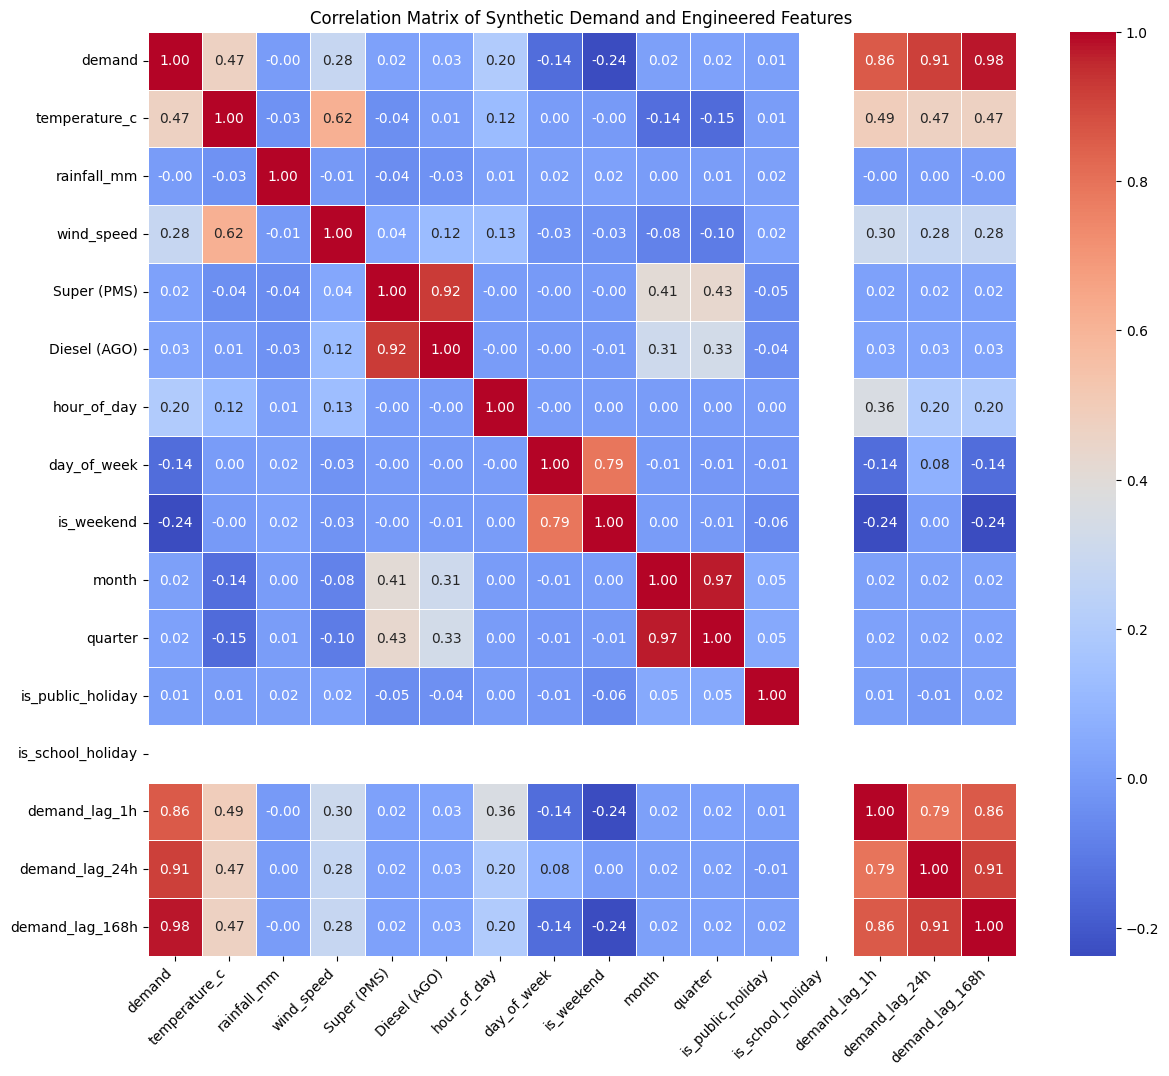

In [25]:
# Ensure 'is_weekend' is present in feature_df right before correlation calculation
# This is a defensive step to handle unexpected state inconsistencies.
if 'is_weekend' not in feature_df.columns:
    # Assuming 'day_of_week' is present from earlier temporal feature engineering
    feature_df['is_weekend'] = (feature_df['day_of_week'] >= 5).astype(int)

# Select features for correlation analysis, including the new synthetic demand
# We'll include weather, fuel prices, temporal features, and holiday flags
correlation_columns_demand = [
    'demand',  # Changed from 'scheduled_demand_count' to 'demand'
    'temperature_c',
    'rainfall_mm',
    'wind_speed',
    'Super (PMS)',
    'Diesel (AGO)',
    'hour_of_day',
    'day_of_week',
    'is_weekend',
    'month',
    'quarter',
    'is_public_holiday',
    'is_school_holiday',
    'demand_lag_1h',
    'demand_lag_24h',
    'demand_lag_168h'
]

# Calculate the correlation matrix
correlation_matrix_demand = feature_df[correlation_columns_demand].corr()

print("Correlation Matrix: Synthetic Demand vs. Other Features:")
display(correlation_matrix_demand)

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix_demand, annot=True,
            cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Synthetic Demand and Engineered Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

## 12. Engineer Interaction Term: `rainfall_x_hour`

Interaction terms are crucial for capturing non-linear relationships between features. Here, we'll create `rainfall_x_hour` by multiplying `rainfall_mm` and `hour_of_day`. This term is designed to capture scenarios where the effect of one variable is dependent on the value of another. For instance, morning rain might have a different, more pronounced impact on demand compared to rain at other times.

This can help the model understand that heavy rain during rush hour has a specific, potentially larger, effect on ridership than rain during off-peak hours or isolated rainfall events.

In [26]:
# Engineer the interaction term: rainfall_x_hour
feature_df['rainfall_x_hour'] = feature_df['rainfall_mm'] * \
    feature_df['hour_of_day']

print("Head of Feature DataFrame with new 'rainfall_x_hour' interaction term:")
display(feature_df.head())

print(
    f"Feature DataFrame shape after adding interaction term: {feature_df.shape}")

Head of Feature DataFrame with new 'rainfall_x_hour' interaction term:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand,rainfall_x_hour
time,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,15.4,0.0,6.5,180.66,168.06,58.816632,25.248310,38.058829,0,0,0,1,1,0,0,26.071919,0.0
2024-01-08 01:00:00,15.4,0.0,6.1,180.66,168.06,26.071919,26.705779,17.756761,1,0,0,1,1,0,0,7.806617,0.0
2024-01-08 02:00:00,16.1,0.0,6.5,180.66,168.06,7.806617,0.000000,30.508280,2,0,0,1,1,0,0,5.603712,0.0
2024-01-08 03:00:00,15.1,0.0,7.0,180.66,168.06,5.603712,0.000000,44.710063,3,0,0,1,1,0,0,6.799509,0.0
2024-01-08 04:00:00,15.7,0.0,9.5,180.66,168.06,6.799509,36.510658,36.201030,4,0,0,1,1,0,0,38.819966,0.0


Feature DataFrame shape after adding interaction term: (18816, 17)


## 13. Engineer Traffic Index Proxy: `traffic_index`

To provide a more comprehensive representation of expected demand, we will create a `traffic_index` feature. This proxy is derived from `hour_of_day` and `is_weekend` using a sigmoid function, scaled to a 0-100 range.

This index is designed to reflect typical public transport demand patterns, where:
*   **Hour of Day:** Demand is generally higher during morning and evening rush hours and lower during off-peak times.
*   **Is Weekend:** Demand is typically lower on weekends compared to weekdays.

The sigmoid function helps to smooth these transitions, providing a continuous index that can capture the varying levels of 'busyness' throughout the week. This feature can serve as a valuable input for models to understand the baseline cyclical demand.

In [27]:
print('--- Engineering Traffic Index Proxy ---')

# Define base scores for each hour of day (0-23)
# These values are chosen to reflect typical traffic patterns, with peaks in morning and evening.
base_hour_scores = {
    # Very low traffic (early morning)
    0: -2.5, 1: -3.0, 2: -3.5, 3: -3.0, 4: -2.0,
    5: -0.5, 6: 1.5,  # Morning build-up
    7: 3.0, 8: 3.5, 9: 2.5,  # Morning peak
    10: 1.0, 11: 0.5, 12: 0.8, 13: 1.2, 14: 1.5,  # Mid-day
    15: 2.0, 16: 3.0, 17: 3.5, 18: 3.0,  # Evening peak
    19: 1.5, 20: 0.5,  # Evening cool-down
    21: -0.5, 22: -1.5, 23: -2.0  # Night
}

# Create a 'raw_traffic_score' column based on hour_of_day
feature_df['raw_traffic_score'] = feature_df['hour_of_day'].map(
    base_hour_scores)

# Adjust for weekends: reduce traffic potential on weekends
# A weekend adjustment factor can be tuned. Subtracting 2.0 significantly lowers weekend scores.
weekend_adjustment = 2.0
feature_df.loc[feature_df['is_weekend'] == 1,
               'raw_traffic_score'] -= weekend_adjustment

# Define the sigmoid function


def sigmoid_scaled(x):
    # Apply sigmoid and scale to 0-100. The scale factor (e.g., 0.8) and offset (e.g., 0.5)
    # inside the exponent can be tuned to adjust the curve's steepness and position.
    return 1 / (1 + np.exp(-(x * 1.0)))


# Apply the sigmoid function to the raw_traffic_score and scale to 0-100
feature_df['traffic_index'] = feature_df['raw_traffic_score'].apply(
    sigmoid_scaled) * 100

# Drop the intermediate 'raw_traffic_score' column
feature_df.drop(columns=['raw_traffic_score'], inplace=True)

print("Head of Feature DataFrame with new 'traffic_index' proxy:")
display(feature_df.head())

print(
    f"Feature DataFrame shape after adding 'traffic_index': {feature_df.shape}")

--- Engineering Traffic Index Proxy ---
Head of Feature DataFrame with new 'traffic_index' proxy:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand,rainfall_x_hour,traffic_index
time,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,15.4,0.0,6.5,180.66,168.06,58.816632,25.248310,38.058829,0,0,0,1,1,0,0,26.071919,0.0,7.585818
2024-01-08 01:00:00,15.4,0.0,6.1,180.66,168.06,26.071919,26.705779,17.756761,1,0,0,1,1,0,0,7.806617,0.0,4.742587
2024-01-08 02:00:00,16.1,0.0,6.5,180.66,168.06,7.806617,0.000000,30.508280,2,0,0,1,1,0,0,5.603712,0.0,2.931223
2024-01-08 03:00:00,15.1,0.0,7.0,180.66,168.06,5.603712,0.000000,44.710063,3,0,0,1,1,0,0,6.799509,0.0,4.742587
2024-01-08 04:00:00,15.7,0.0,9.5,180.66,168.06,6.799509,36.510658,36.201030,4,0,0,1,1,0,0,38.819966,0.0,11.920292


Feature DataFrame shape after adding 'traffic_index': (18816, 18)


## 14. One-Hot Encode `route_id` and Save Encoder

This step prepares the `route_id` for use in machine learning models by converting it into a numerical, binary format. We will fit a `OneHotEncoder` on the unique `route_id`s found in the `routes_df` (which represents the complete set of routes). This encoder will then be saved to a file (`encoder.pkl`) for later use, ensuring consistency when applying it to training, validation, and test datasets.

**Note on 'Training Split':** For a static categorical feature like `route_id`, the encoder is typically fitted on all unique categories present in the entire dataset to ensure all possible routes are covered. When a larger dataset (e.g., route-specific demand over time) is later split into training and testing sets, this pre-fitted encoder will be applied to both splits to transform the `route_id` column, thus preventing data leakage.

In [28]:
print('--- One-Hot Encoding route_id and Saving Encoder ---')

# Ensure routes_df is available (it was loaded in cell g3UB_kJoGJ3_)
# Extract unique route_ids and reshape for OneHotEncoder
route_ids = routes_df['route_id'].unique().reshape(-1, 1)

# Initialize OneHotEncoder
# handle_unknown='ignore' ensures that if a route_id not seen during fitting appears,
# it won't raise an error and will instead encode it as all zeros.
# sparse_output=False ensures the output is a dense array rather than a sparse matrix.
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit the encoder on the unique route_ids
encoder.fit(route_ids)

# Define the path to save the encoder
encoder_path = os.path.join(processed_data_dir, 'route_id_onehot_encoder.pkl')

# Save the fitted encoder
joblib.dump(encoder, encoder_path)

print(f"Fitted OneHotEncoder for route_id saved to: {encoder_path}")
print(f"Number of unique routes used for encoding: {len(route_ids)}")
print("Example of transformed route_id (first 5 unique routes):")
display(encoder.transform(route_ids[:5]))

--- One-Hot Encoding route_id and Saving Encoder ---
Fitted OneHotEncoder for route_id saved to: /content/drive/MyDrive/matatu_ml/data/processed/route_id_onehot_encoder.pkl
Number of unique routes used for encoding: 136
Example of transformed route_id (first 5 unique routes):


array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.,

## 14. Generate Proxy Demand Labels: Binning into Quantiles

This phase involves transforming a continuous proxy score, in this case, the `traffic_index` we just engineered, into discrete categorical labels. We will divide the range of the `traffic_index` into three quantiles: Low (0-33%), Medium (34-66%), and High (67-100%).

### Why is this important?

1.  **Simplification for Classification Tasks:** While the `demand` column is continuous and ideal for regression, having categorical demand labels allows for different modeling approaches, specifically classification. Instead of predicting an exact number, a model could predict if demand will be 'Low', 'Medium', or 'High'.
2.  **Operational Decision Making:** For real-world public transport operations, discrete categories might be more actionable than precise numerical predictions. For example, 'High' demand might trigger a decision to deploy additional vehicles or staff, while 'Low' demand might lead to reducing service frequency.
3.  **Feature for Further Modeling:** These categorical labels can themselves be used as a target variable or even as an additional categorical feature in other predictive models.
4.  **Interpretability:** Categorical labels are often easier to understand and communicate to stakeholders than continuous values, providing a clearer picture of demand states.

By creating these binned labels, we add another dimension to our demand analysis, preparing the data for a wider range of machine learning techniques and business applications.

In [29]:
# Calculate the 33rd and 66th percentiles of the 'traffic_index'
low_threshold = feature_df['traffic_index'].quantile(0.33)
medium_threshold = feature_df['traffic_index'].quantile(0.66)

# Define a function to assign labels based on these thresholds


def assign_demand_label(traffic_index_score):
    if traffic_index_score <= low_threshold:
        return 'Low'
    elif traffic_index_score <= medium_threshold:
        return 'Medium'
    else:
        return 'High'


# Apply the function to create the new 'demand_label' column
feature_df['demand_label'] = feature_df['traffic_index'].apply(
    assign_demand_label)

print(f"Low Demand Threshold (33rd percentile): {low_threshold:.2f}")
print(f"Medium Demand Threshold (66th percentile): {medium_threshold:.2f}")

print("\nDistribution of generated demand labels:")
display(feature_df['demand_label'].value_counts())

print("\nHead of Feature DataFrame with new 'demand_label' column:")
display(feature_df.head())

print(
    f"Feature DataFrame shape after adding demand labels: {feature_df.shape}")

Low Demand Threshold (33rd percentile): 18.24
Medium Demand Threshold (66th percentile): 76.85

Distribution of generated demand labels:


,count
demand_label,
Low,6384
Medium,6384
High,6048



Head of Feature DataFrame with new 'demand_label' column:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand,rainfall_x_hour,traffic_index,demand_label
time,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,15.4,0.0,6.5,180.66,168.06,58.816632,25.248310,38.058829,0,0,0,1,1,0,0,26.071919,0.0,7.585818,Low
2024-01-08 01:00:00,15.4,0.0,6.1,180.66,168.06,26.071919,26.705779,17.756761,1,0,0,1,1,0,0,7.806617,0.0,4.742587,Low
2024-01-08 02:00:00,16.1,0.0,6.5,180.66,168.06,7.806617,0.000000,30.508280,2,0,0,1,1,0,0,5.603712,0.0,2.931223,Low
2024-01-08 03:00:00,15.1,0.0,7.0,180.66,168.06,5.603712,0.000000,44.710063,3,0,0,1,1,0,0,6.799509,0.0,4.742587,Low
2024-01-08 04:00:00,15.7,0.0,9.5,180.66,168.06,6.799509,36.510658,36.201030,4,0,0,1,1,0,0,38.819966,0.0,11.920292,Low


Feature DataFrame shape after adding demand labels: (18816, 19)


## 15. Min-Max Scale Numerical Features and Save Scaler

This step involves scaling all numerical features in the `feature_df` to a (0-1) range using `MinMaxScaler`. It's critical to fit the scaler *only* on the training data to prevent data leakage, ensuring that the test set remains truly unseen during the scaling process.

First, we'll perform a temporal split of the `feature_df` to create distinct training and testing datasets. Then, the `MinMaxScaler` will be fitted on the training data and applied to both splits.

In [34]:
# Define the new path to save the scaler
new_scaler_path = os.path.join(processed_data_dir, 'scaler.pkl')

# Save the fitted scaler with the new name
joblib.dump(scaler, new_scaler_path)

print(f"Fitted MinMaxScaler saved to: {new_scaler_path}")

Fitted MinMaxScaler saved to: /content/drive/MyDrive/matatu_ml/data/processed/scaler.pkl


## 15. Visualize Demand Over Time for Seasonal Patterns

To identify seasonal patterns, we will plot the `demand` column from our `feature_df` over the entire time period. This will allow us to visually inspect daily, weekly, and yearly cycles in the synthetic demand.

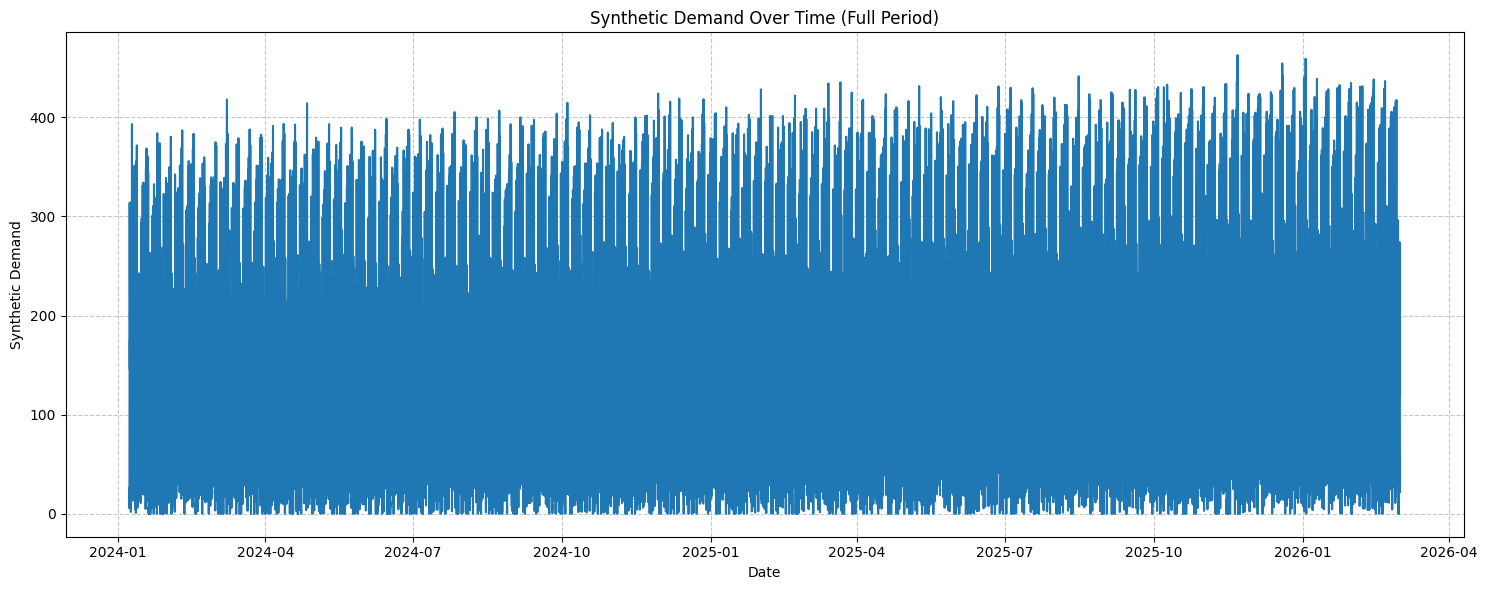

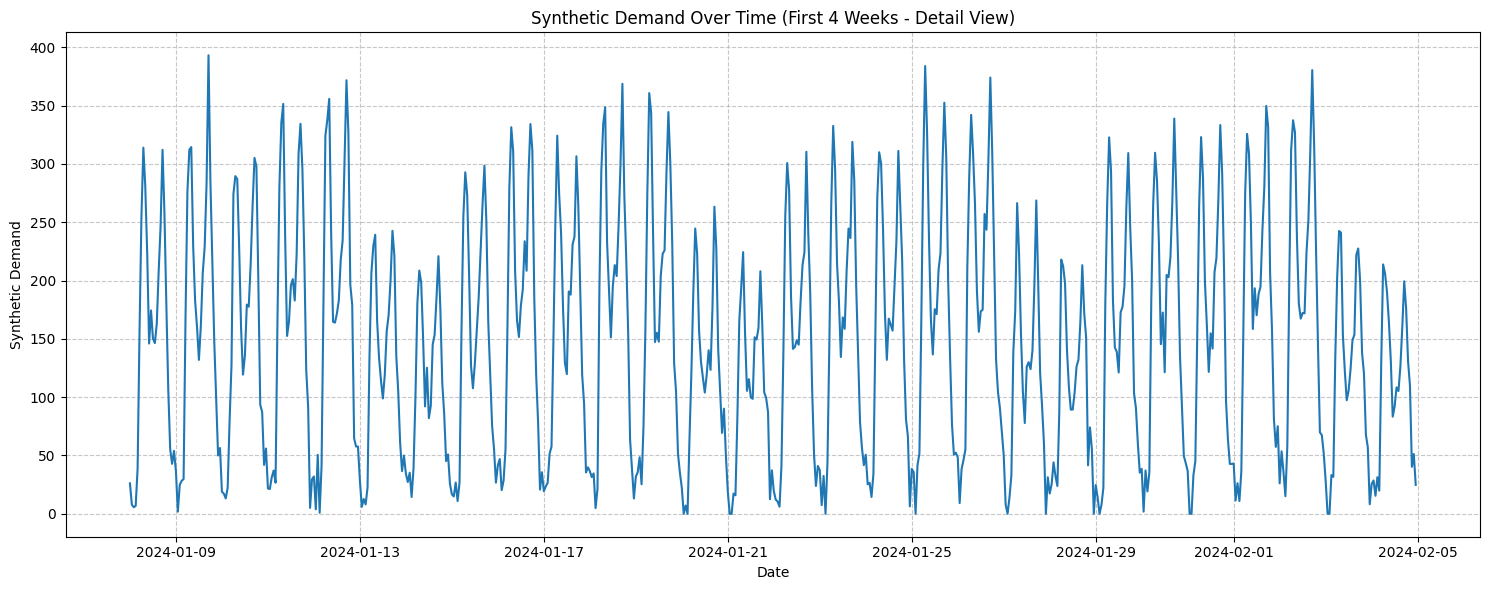

In [31]:
plt.figure(figsize=(15, 6))
sns.lineplot(x=feature_df.index, y='demand', data=feature_df)
plt.title('Synthetic Demand Over Time (Full Period)')
plt.xlabel('Date')
plt.ylabel('Synthetic Demand')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot a smaller segment to observe daily/weekly patterns more clearly
plt.figure(figsize=(15, 6))
sns.lineplot(x=feature_df.index[:24*7*4], y='demand',
             data=feature_df.iloc[:24*7*4])  # First 4 weeks
plt.title('Synthetic Demand Over Time (First 4 Weeks - Detail View)')
plt.xlabel('Date')
plt.ylabel('Synthetic Demand')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 16. Export Final Feature Store to Parquet

Now that all feature engineering and preprocessing steps are complete, we will export the `feature_df` to a Parquet file. Parquet is an efficient columnar storage format that is ideal for large datasets, offering improved performance for reading and writing data compared to CSV. This will allow for fast re-loading of the prepared data in subsequent modeling phases.

In [32]:
final_feature_store_path = os.path.join(
    processed_data_dir, 'feature_store_v1.parquet')

# Ensure the index is preserved, as it contains the time information
feature_df.to_parquet(final_feature_store_path, index=True)

print(
    f"Final feature store (feature_df) exported to: {final_feature_store_path}")

Final feature store (feature_df) exported to: /content/drive/MyDrive/matatu_ml/data/processed/feature_store_v1.parquet


In [33]:
print('--- Temporal Train/Test Split and Min-Max Scaling Numerical Features ---')

# Ensure feature_df index is datetime for temporal splitting
if not isinstance(feature_df.index, pd.DatetimeIndex):
    feature_df.index = pd.to_datetime(feature_df.index)

# Define the split point for temporal data
# Training data: 2024, Testing data: 2025
# So, test data starts from January 1, 2025
split_date = pd.to_datetime('2025-01-01')

train_df = feature_df[feature_df.index < split_date].copy()
test_df = feature_df[feature_df.index >= split_date].copy()

print(f"Original feature_df shape: {feature_df.shape}")
print(f"Train_df shape (2024 data): {train_df.shape}")
print(f"Test_df shape (2025 data): {test_df.shape}")

# Identify numerical columns for scaling
# Exclude 'is_public_holiday', 'is_school_holiday', 'is_weekend' if they are already binary and don't need scaling
# Or include them if a blanket scaling is desired. For now, we'll scale all numeric.
numerical_cols = train_df.select_dtypes(include=['number']).columns.tolist()

# Some features are already binary (0 or 1) and don't strictly need scaling,
# but including them in Min-Max scaling to (0-1) won't harm.
# If you prefer to exclude them, modify the list below:
# numerical_cols_to_exclude_from_scaling = ['is_public_holiday', 'is_school_holiday', 'is_weekend']
# numerical_cols = [col for col in numerical_cols if col not in numerical_cols_to_exclude_from_scaling]

print(f"Number of numerical features to scale: {len(numerical_cols)}")

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler ONLY on the training data for numerical features
scaler.fit(train_df[numerical_cols])

# Transform both training and testing data
train_df[numerical_cols] = scaler.transform(train_df[numerical_cols])
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

# Define the path to save the scaler
scaler_path = os.path.join(processed_data_dir, 'minmax_scaler.pkl')

# Save the fitted scaler
joblib.dump(scaler, scaler_path)

print(f"Fitted MinMaxScaler saved to: {scaler_path}")

print("\nHead of scaled training DataFrame:")
display(train_df.head())

print("\nHead of scaled testing DataFrame:")
display(test_df.head())

print(f"Train_df shape after scaling: {train_df.shape}")
print(f"Test_df shape after scaling: {test_df.shape}")

# Save the train and test dataframes to parquet files
train_output_path = os.path.join(processed_data_dir, 'train.parquet')
test_output_path = os.path.join(processed_data_dir, 'test.parquet')

train_df.to_parquet(train_output_path, index=True)
test_df.to_parquet(test_output_path, index=True)

print(f"Train data saved to: {train_output_path}")
print(f"Test data saved to: {test_output_path}")

--- Temporal Train/Test Split and Min-Max Scaling Numerical Features ---
Original feature_df shape: (18816, 19)
Train_df shape (2024 data): (8616, 19)
Test_df shape (2025 data): (10200, 19)
Number of numerical features to scale: 18
Fitted MinMaxScaler saved to: /content/drive/MyDrive/matatu_ml/data/processed/minmax_scaler.pkl

Head of scaled training DataFrame:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand,rainfall_x_hour,traffic_index,demand_label
time,,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,0.276498,0.0,0.268595,1.0,1.0,0.138699,0.059540,0.089749,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.061482,0.0,0.074267,Low
2024-01-08 01:00:00,0.276498,0.0,0.252066,1.0,1.0,0.061482,0.062976,0.041873,0.043478,0.0,0.0,0.0,0.0,0.0,0.0,0.018409,0.0,0.044853,Low
2024-01-08 02:00:00,0.308756,0.0,0.268595,1.0,1.0,0.018409,0.000000,0.071943,0.086957,0.0,0.0,0.0,0.0,0.0,0.0,0.013214,0.0,0.026114,Low
2024-01-08 03:00:00,0.262673,0.0,0.289256,1.0,1.0,0.013214,0.000000,0.105433,0.130435,0.0,0.0,0.0,0.0,0.0,0.0,0.016034,0.0,0.044853,Low
2024-01-08 04:00:00,0.290323,0.0,0.392562,1.0,1.0,0.016034,0.086098,0.085368,0.173913,0.0,0.0,0.0,0.0,0.0,0.0,0.091544,0.0,0.119109,Low



Head of scaled testing DataFrame:


,temperature_c,rainfall_mm,wind_speed,Super (PMS),Diesel (AGO),demand_lag_1h,demand_lag_24h,demand_lag_168h,hour_of_day,day_of_week,is_weekend,month,quarter,is_public_holiday,is_school_holiday,demand,rainfall_x_hour,traffic_index,demand_label
time,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,0.299539,0.0,0.219008,0.0,0.0,0.068787,0.122176,0.023750,0.000000,0.333333,0.0,0.0,0.0,1.0,0.0,0.035104,0.0,0.074267,Low
2025-01-01 01:00:00,0.294931,0.0,0.247934,0.0,0.0,0.035104,0.007118,0.081818,0.043478,0.333333,0.0,0.0,0.0,1.0,0.0,0.062728,0.0,0.044853,Low
2025-01-01 02:00:00,0.276498,0.0,0.223140,0.0,0.0,0.062728,0.011238,0.080563,0.086957,0.333333,0.0,0.0,0.0,1.0,0.0,0.078189,0.0,0.026114,Low
2025-01-01 03:00:00,0.248848,0.0,0.157025,0.0,0.0,0.078189,0.078822,0.114644,0.130435,0.333333,0.0,0.0,0.0,1.0,0.0,0.042668,0.0,0.044853,Low
2025-01-01 04:00:00,0.262673,0.0,0.152893,0.0,0.0,0.042668,0.110885,0.077819,0.173913,0.333333,0.0,0.0,0.0,1.0,0.0,0.134209,0.0,0.119109,Low


Train_df shape after scaling: (8616, 19)
Test_df shape after scaling: (10200, 19)
Train data saved to: /content/drive/MyDrive/matatu_ml/data/processed/train.parquet
Test data saved to: /content/drive/MyDrive/matatu_ml/data/processed/test.parquet


## Exploratory Data Analysis (EDA)

### 1. Distribution Plots for Key Numerical Features

These plots help us understand the spread, central tendency, and shape of our numerical features. They can reveal skewness, presence of outliers, and general data characteristics crucial for model building.

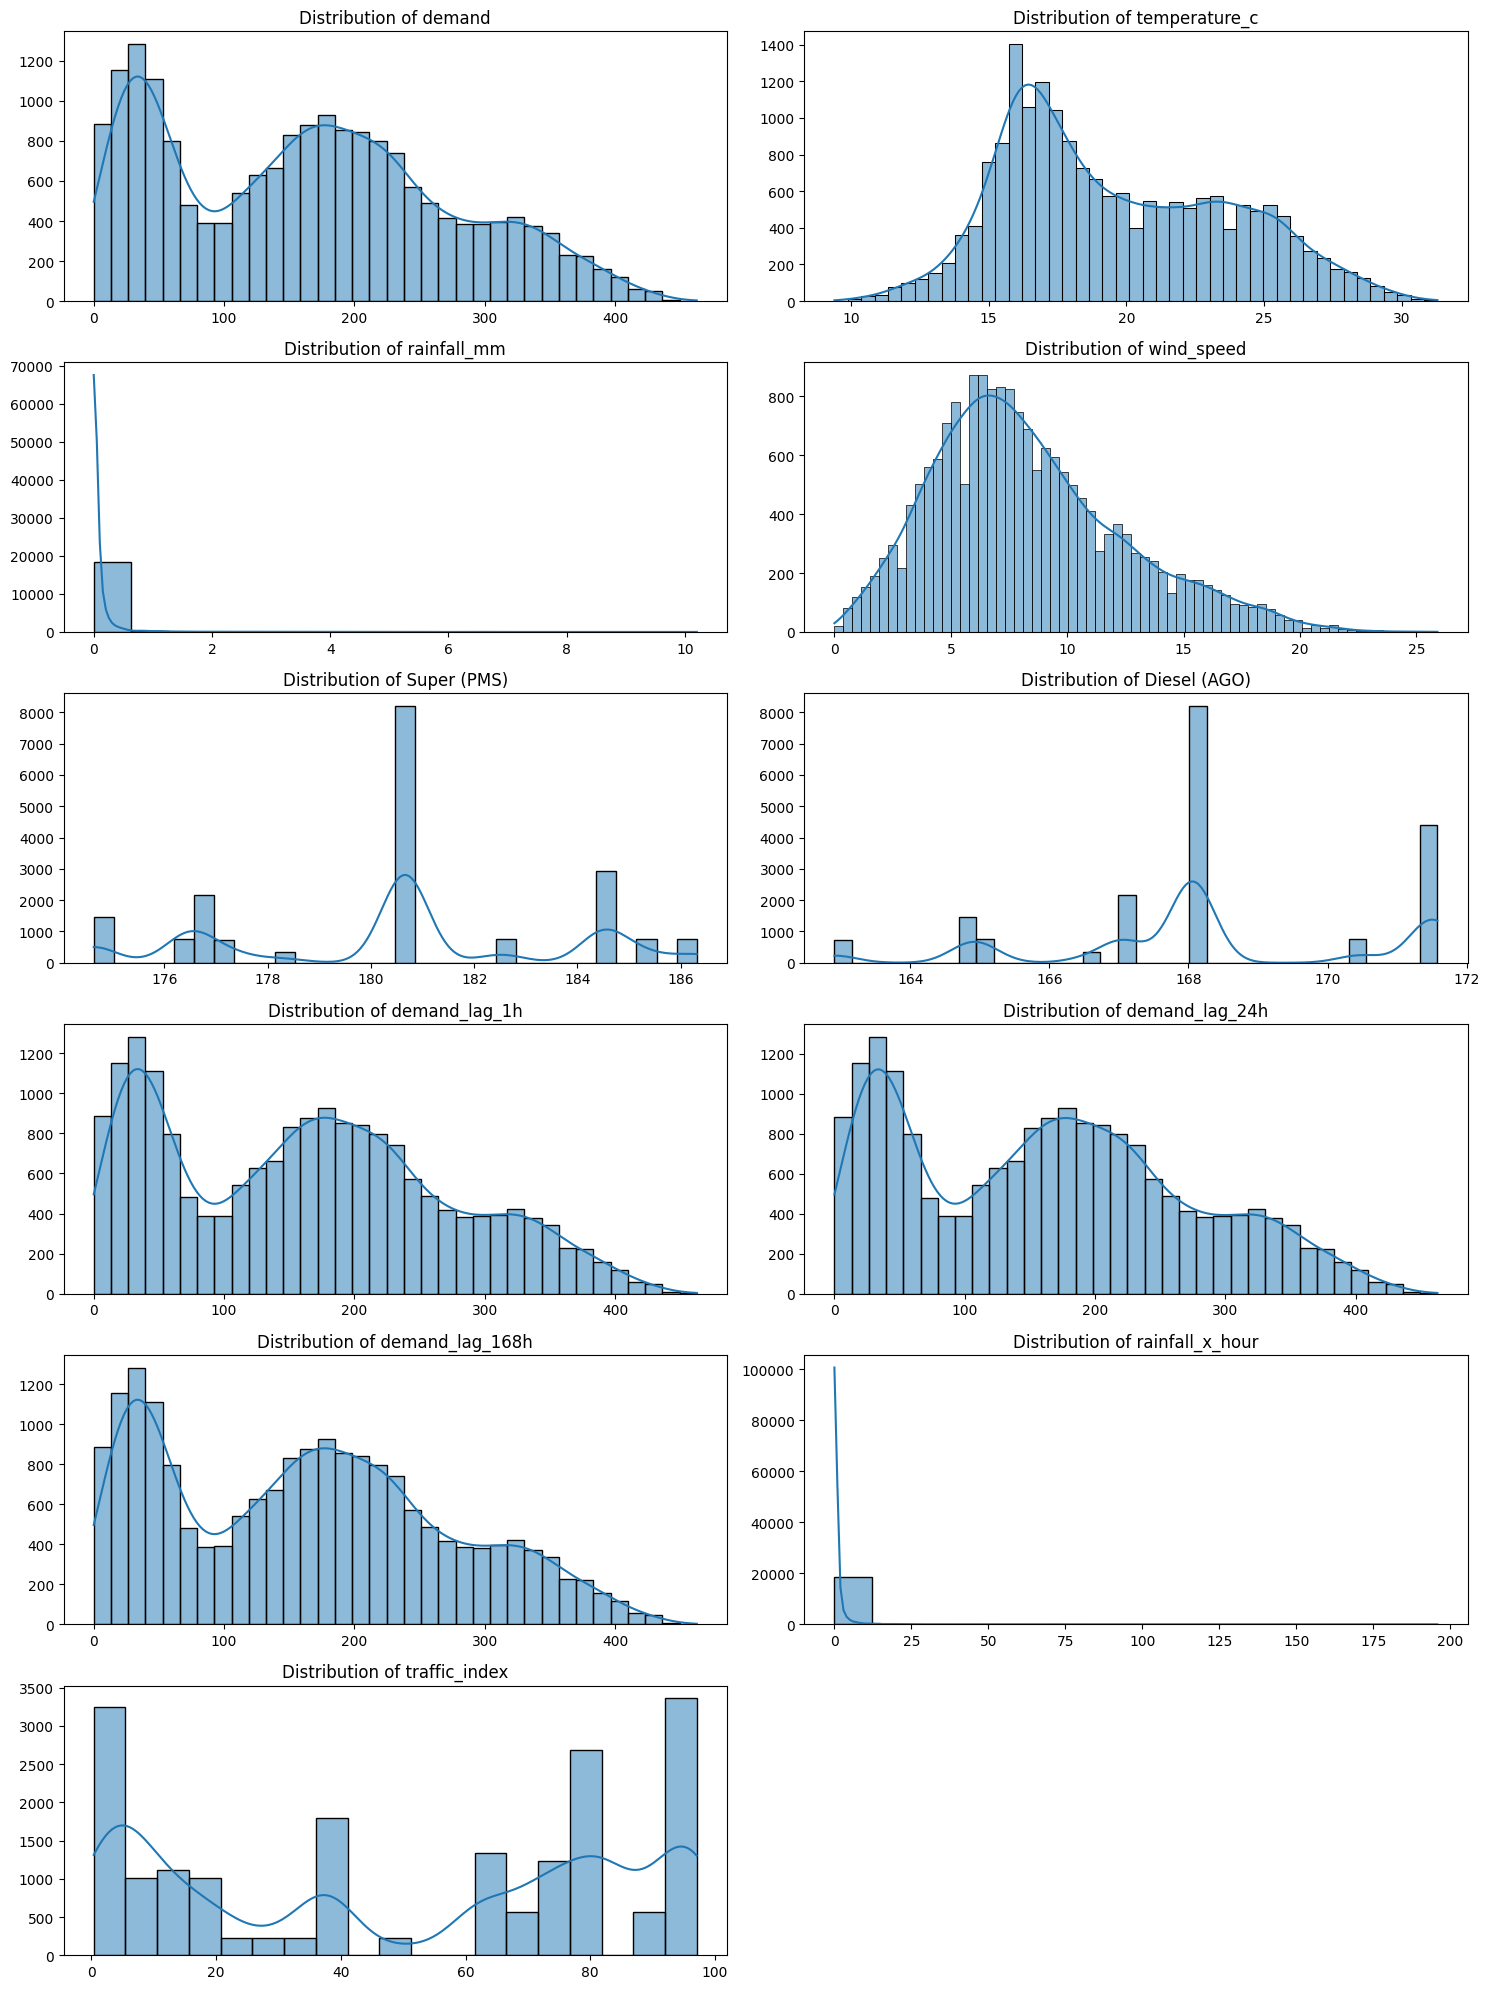

In [35]:
# Select numerical columns for distribution plots
# Exclude binary columns and ID-like columns that are not truly numerical distributions

numerical_features = [
    'demand',
    'temperature_c',
    'rainfall_mm',
    'wind_speed',
    'Super (PMS)',
    'Diesel (AGO)',
    'demand_lag_1h',
    'demand_lag_24h',
    'demand_lag_168h',
    'rainfall_x_hour',
    'traffic_index'
]

plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_features):
    plt.subplot(6, 2, i + 1)  # Adjust subplot grid as needed
    sns.histplot(feature_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### 2. Correlation Heatmap

A correlation heatmap visualizes the pairwise correlation coefficients between all features. This helps identify strongly correlated features, which can indicate multicollinearity, or features that have a strong relationship with the target variable (`demand`).

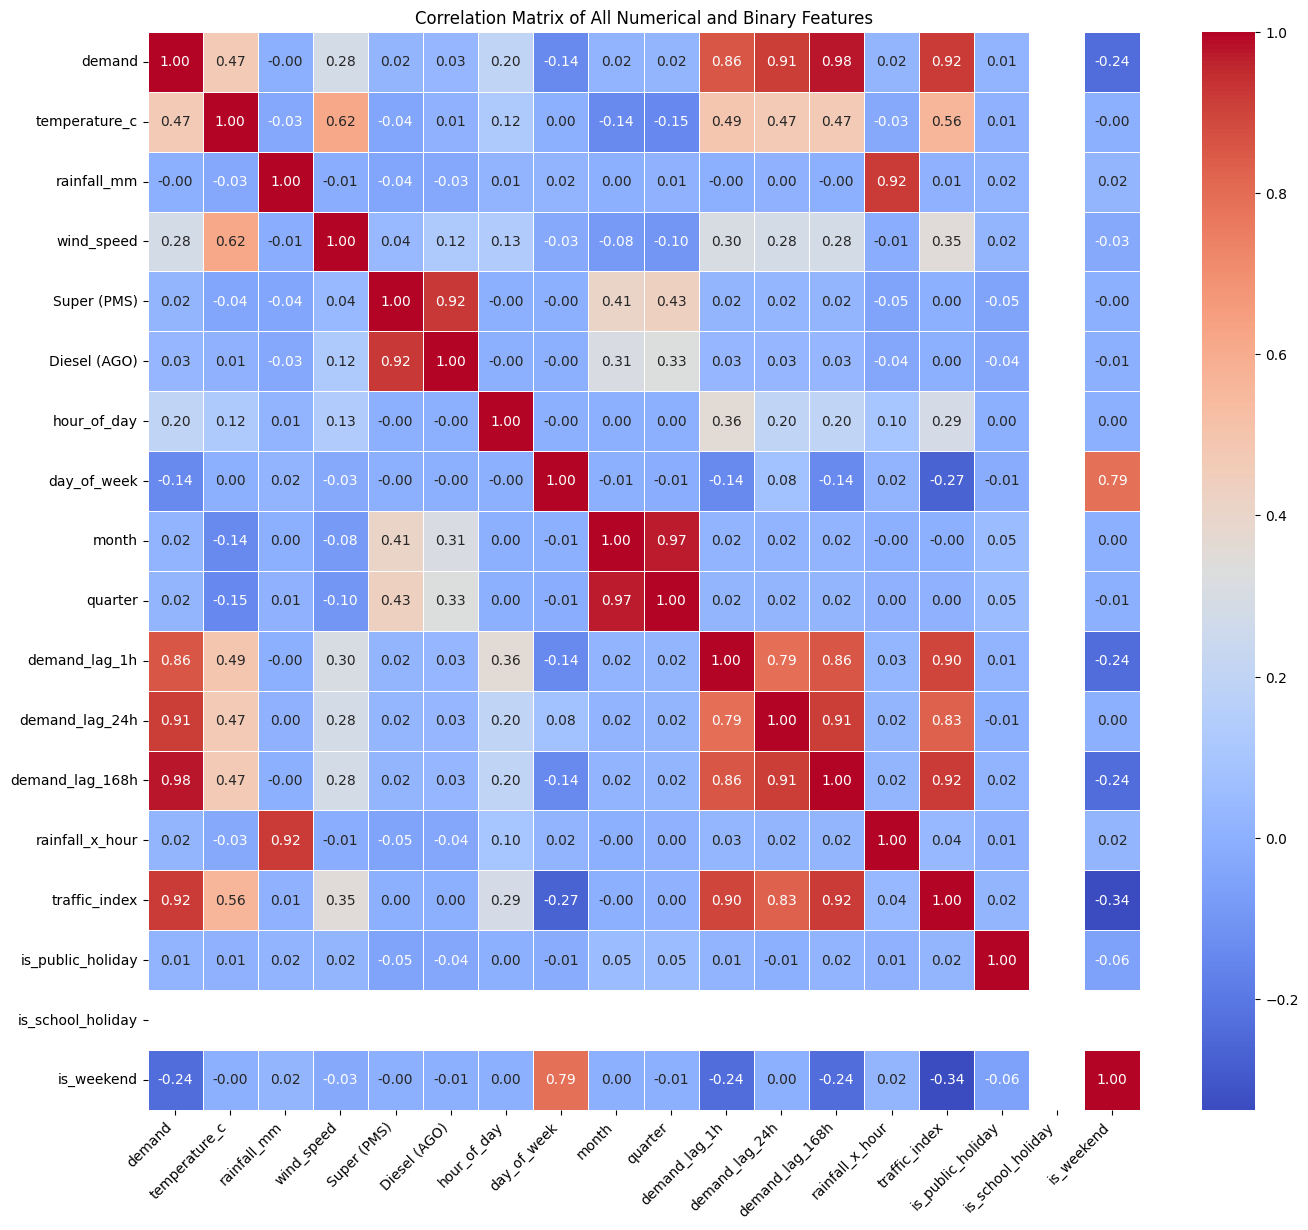

In [36]:
# Select relevant numerical columns for correlation analysis
# Exclude 'is_public_holiday', 'is_school_holiday', 'is_weekend' as they are binary and already covered
# Exclude 'demand_label' as it's a categorical target derived from traffic_index

correlation_features = [
    'demand',
    'temperature_c',
    'rainfall_mm',
    'wind_speed',
    'Super (PMS)',
    'Diesel (AGO)',
    'hour_of_day',
    'day_of_week',
    'month',
    'quarter',
    'demand_lag_1h',
    'demand_lag_24h',
    'demand_lag_168h',
    'rainfall_x_hour',
    'traffic_index',
    'is_public_holiday',
    'is_school_holiday',
    'is_weekend'
]

# Calculate the correlation matrix
correlation_matrix = feature_df[correlation_features].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True,
            cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Numerical and Binary Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

### 3. Peak-Hour Demand Bar Charts

These bar charts illustrate how `demand` varies by `hour_of_day` and `day_of_week`, revealing daily and weekly patterns crucial for understanding public transport usage. They help identify rush hours and differences in demand between weekdays and weekends.

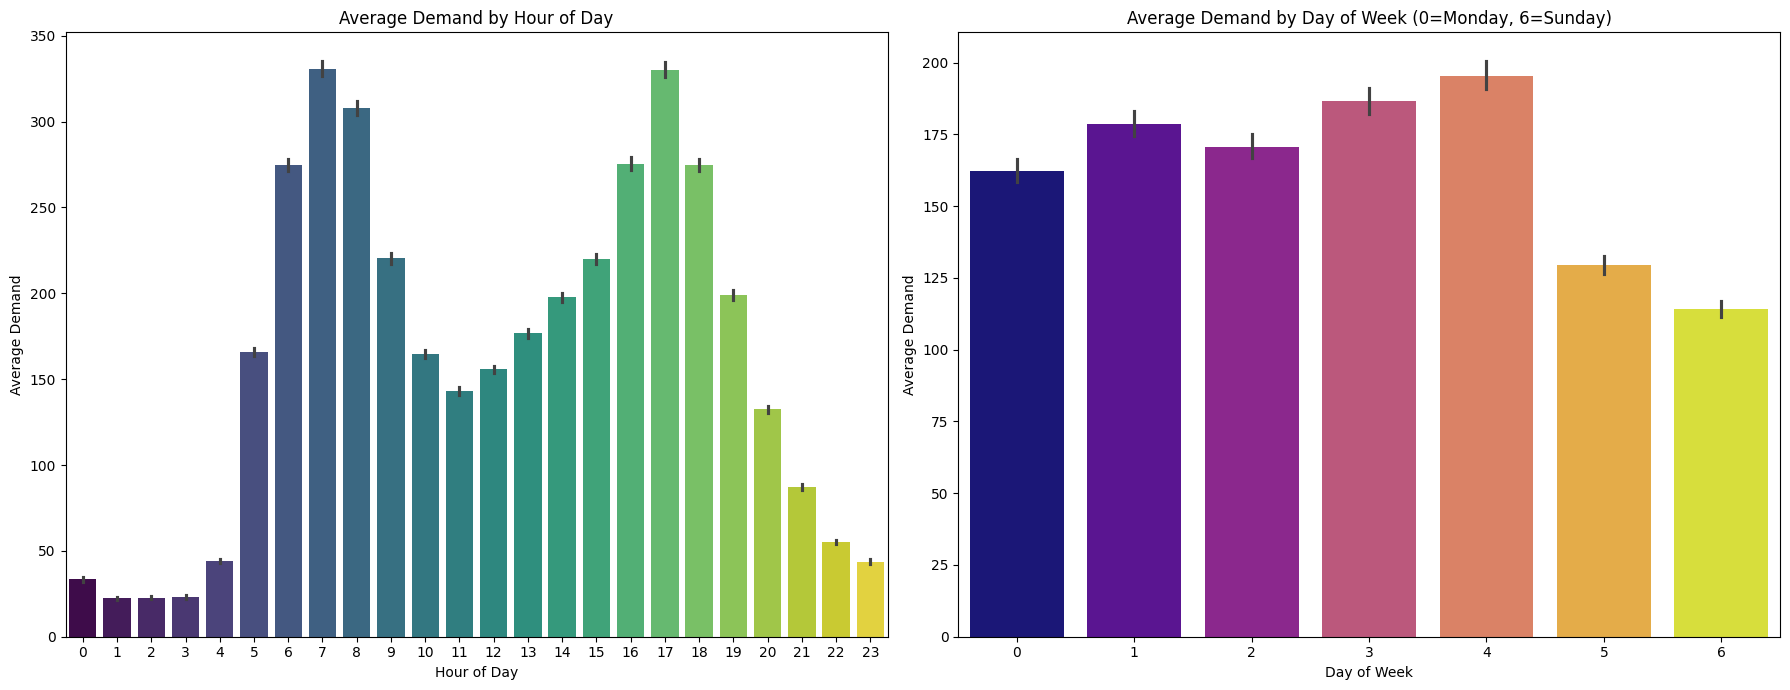

In [37]:
plt.figure(figsize=(18, 7))

# Demand by Hour of Day
plt.subplot(1, 2, 1)
sns.barplot(x='hour_of_day', y='demand', data=feature_df,
            estimator=np.mean, palette='viridis', hue='hour_of_day', legend=False)
plt.title('Average Demand by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')

# Demand by Day of Week
plt.subplot(1, 2, 2)
sns.barplot(x='day_of_week', y='demand', data=feature_df,
            estimator=np.mean, palette='plasma', hue='day_of_week', legend=False)
plt.title('Average Demand by Day of Week (0=Monday, 6=Sunday)')
plt.xlabel('Day of Week')
plt.ylabel('Average Demand')

plt.tight_layout()
plt.show()

### 4. Spatial Demand Map (Folium)

To visualize the spatial distribution of potential demand, we will use the `stops_gdf` which contains `poi_count_500m`. This map will highlight areas with high concentrations of Points of Interest (POIs) around public transport stops, serving as a proxy for activity and potential ridership.

Since `feature_df` does not directly contain spatial information, we use `stops_gdf` which has been enriched with `poi_count_500m` to represent spatial demand. The `poi_count_500m` acts as an indicator of how busy or important a stop might be, implying higher potential demand.

In [38]:
# Ensure stops_gdf is available and has 'poi_count_500m' and geometry
# If not, load it or re-run the relevant preprocessing steps.
# For this demonstration, we'll assume stops_gdf is properly loaded from earlier cells.

# Get the centroid of Nairobi for map centering
map_center = [-1.286389, 36.817223]  # Approximate center of Nairobi

# Create a Folium map
m = folium.Map(location=map_center, zoom_start=12)

# Add a HeatMap layer for POI density
# Filter out stops with no POIs for better visualization of active areas
active_stops = stops_gdf[stops_gdf['poi_count_500m'] > 0].copy()

# Prepare data for heatmap (latitude, longitude, intensity)
heat_data = [[row.geometry.y, row.geometry.x, row['poi_count_500m']]
             for idx, row in active_stops.iterrows()]

# Add HeatMap to the map
folium.plugins.HeatMap(heat_data, radius=15).add_to(m)

# Optionally, add markers for individual stops (can be slow for many stops)
# For better performance, we'll only add a few example markers or rely on heatmap.
# If you want to add markers for all stops, be aware of performance.
# for idx, row in stops_gdf.sample(min(200, len(stops_gdf))).iterrows(): # Sample for performance
#     folium.CircleMarker(
#         location=[row.geometry.y, row.geometry.x],
#         radius=5,
#         color='blue',
#         fill=True,
#         fill_color='blue',
#         tooltip=f"Stop: {row['stop_name']}<br>POIs: {row['poi_count_500m']}"
#     ).add_to(m)

# Display the map
m

### 5. Save EDA Report

This cell will save the current Jupyter Notebook as an HTML file (`eda_report.html`), allowing for easy sharing and viewing of the entire EDA process and its results.

In [39]:
print('Current working directory:')
!pwd
print('\nFiles in current directory:')
!ls -F

notebook_name = '02_preprocessing.ipynb'
project_base_dir = '/content/drive/MyDrive/matatu_ml/'

# Verify if the notebook exists in the assumed project_base_dir
print(f'\nVerifying project base directory access: {project_base_dir}')
!ls -l "{project_base_dir}"

# This is a crucial diagnostic step: list all files in the root of MyDrive
print(f'\nListing ALL contents of /content/drive/MyDrive/ to locate the notebook:')
!ls -l '/content/drive/MyDrive/'

# Correcting the assumption based on typical Colab notebook locations
# The notebook is often located in 'Colab Notebooks' folder within MyDrive
notebook_actual_source_path = os.path.join(
    '/content/drive/MyDrive/Colab Notebooks/', notebook_name)

# Define the output path for the HTML report within the project_base_dir
output_html_report_path = os.path.join(project_base_dir, 'eda_report.html')

print(f'\nAttempting to convert notebook from: {notebook_actual_source_path}')
print(f'\nOutputting HTML report to: {output_html_report_path}')

# Use jupyter nbconvert with the absolute paths for both source and destination
!jupyter nbconvert --to html --output "{output_html_report_path}" "{notebook_actual_source_path}"

Current working directory:
/content

Files in current directory:
 drive/
 nairobi_weather_2024.json
'Pump Prices  Energy and Petroleum Regulatory Authority.csv'
 sample_data/

Verifying project base directory access: /content/drive/MyDrive/matatu_ml/
total 1625
drwx------ 4 root root    4096 Apr 30 05:35 data
-rw------- 1 root root 1646710 May  2 17:46 eda_report.html
drwx------ 2 root root    4096 May  1 06:37 models
drwx------ 2 root root    4096 Apr 30 14:55 outputs
drwx------ 2 root root    4096 May  5 04:10 reports

Listing ALL contents of /content/drive/MyDrive/ to locate the notebook:
total 899
-rw------- 1 root root  25627 Apr 28 20:05  4_6019062817536089592.xlsx
-rw------- 1 root root    178 Apr 28 20:18 'CAT 3 OO47 2022.gsheet'
drwx------ 2 root root   4096 Apr 28 13:33 'Colab Notebooks'
-rw------- 1 root root 333433 Apr 27 11:56 'Life Expectancy Data csv.csv'
-rw------- 1 root root    178 Apr 28 08:43 'life expectancy .gsheet'
-rw------- 1 root root    178 Apr 27 13:56 'life